# **BERT Fine-Tuning for FOMC Stance Classification**

This notebook fine-tunes `bert-base-uncased` for sentence-level FOMC hawkish / dovish / neutral
classification on the already-provided augmented training data, and reports results on the
official held-out test set.

# **Introduction, Motivation and Problem Statement**

Federal Open Market Committee (FOMC) communications, are closely
watched by financial markets since shifts in monetary policy language can move asset
prices well before any policy action is actually taken, and the content of those communications include meeting minutes, press
conference transcripts, and speeches by Federal Reserve officials. There were three types of policy stance, the statement expressing tightening representing Hawkish, the one expressing loosening representing Dovish, another representing Neutral. Because it is difficult to manually parse this language for its underlying policy stance and this manual method is hard to scale to the volume of communication
the Fed produces, then we can know that there is need to use an automated text classification approach.

In this project, we address the need as a three-class sentence-level classification task, that
given a sentence drawn from FOMC meeting minutes, press conferences, or speeches,
predict whether it expresses a **Hawkish**, **Dovish**, or **Neutral** policy stance.

**Prior work.** This task and dataset were introduced by Shah et al. (2023) in
*"Trillion Dollar Words: A New Financial Dataset, Task & Market Analysis"*
(arXiv:2305.07972)[https://arxiv.org/pdf/2305.07972](https://arxiv.org/pdf/2305.07972), who released an annotated corpus of FOMC sentences and
benchmarked a range of models on the classification task of those three types,
including rule-based baselines, LSTM, Bi-LSTM, and several pretrained transformer
models fine-tuned on the training data. On the "Combined" data split, which contains meeting
minutes, press conferences, speeches combined and averaged over 3 official seeds,
their reported fine-tuned BERT-base-uncased baseline achieved a weighted F1 of
**0.6310** (std. 0.0086) - noticeably behind larger models such as RoBERTa-large
(0.7171) in their benchmark, which reflects the general difficulty of the task rather
than any specific weakness of BERT-base alone.

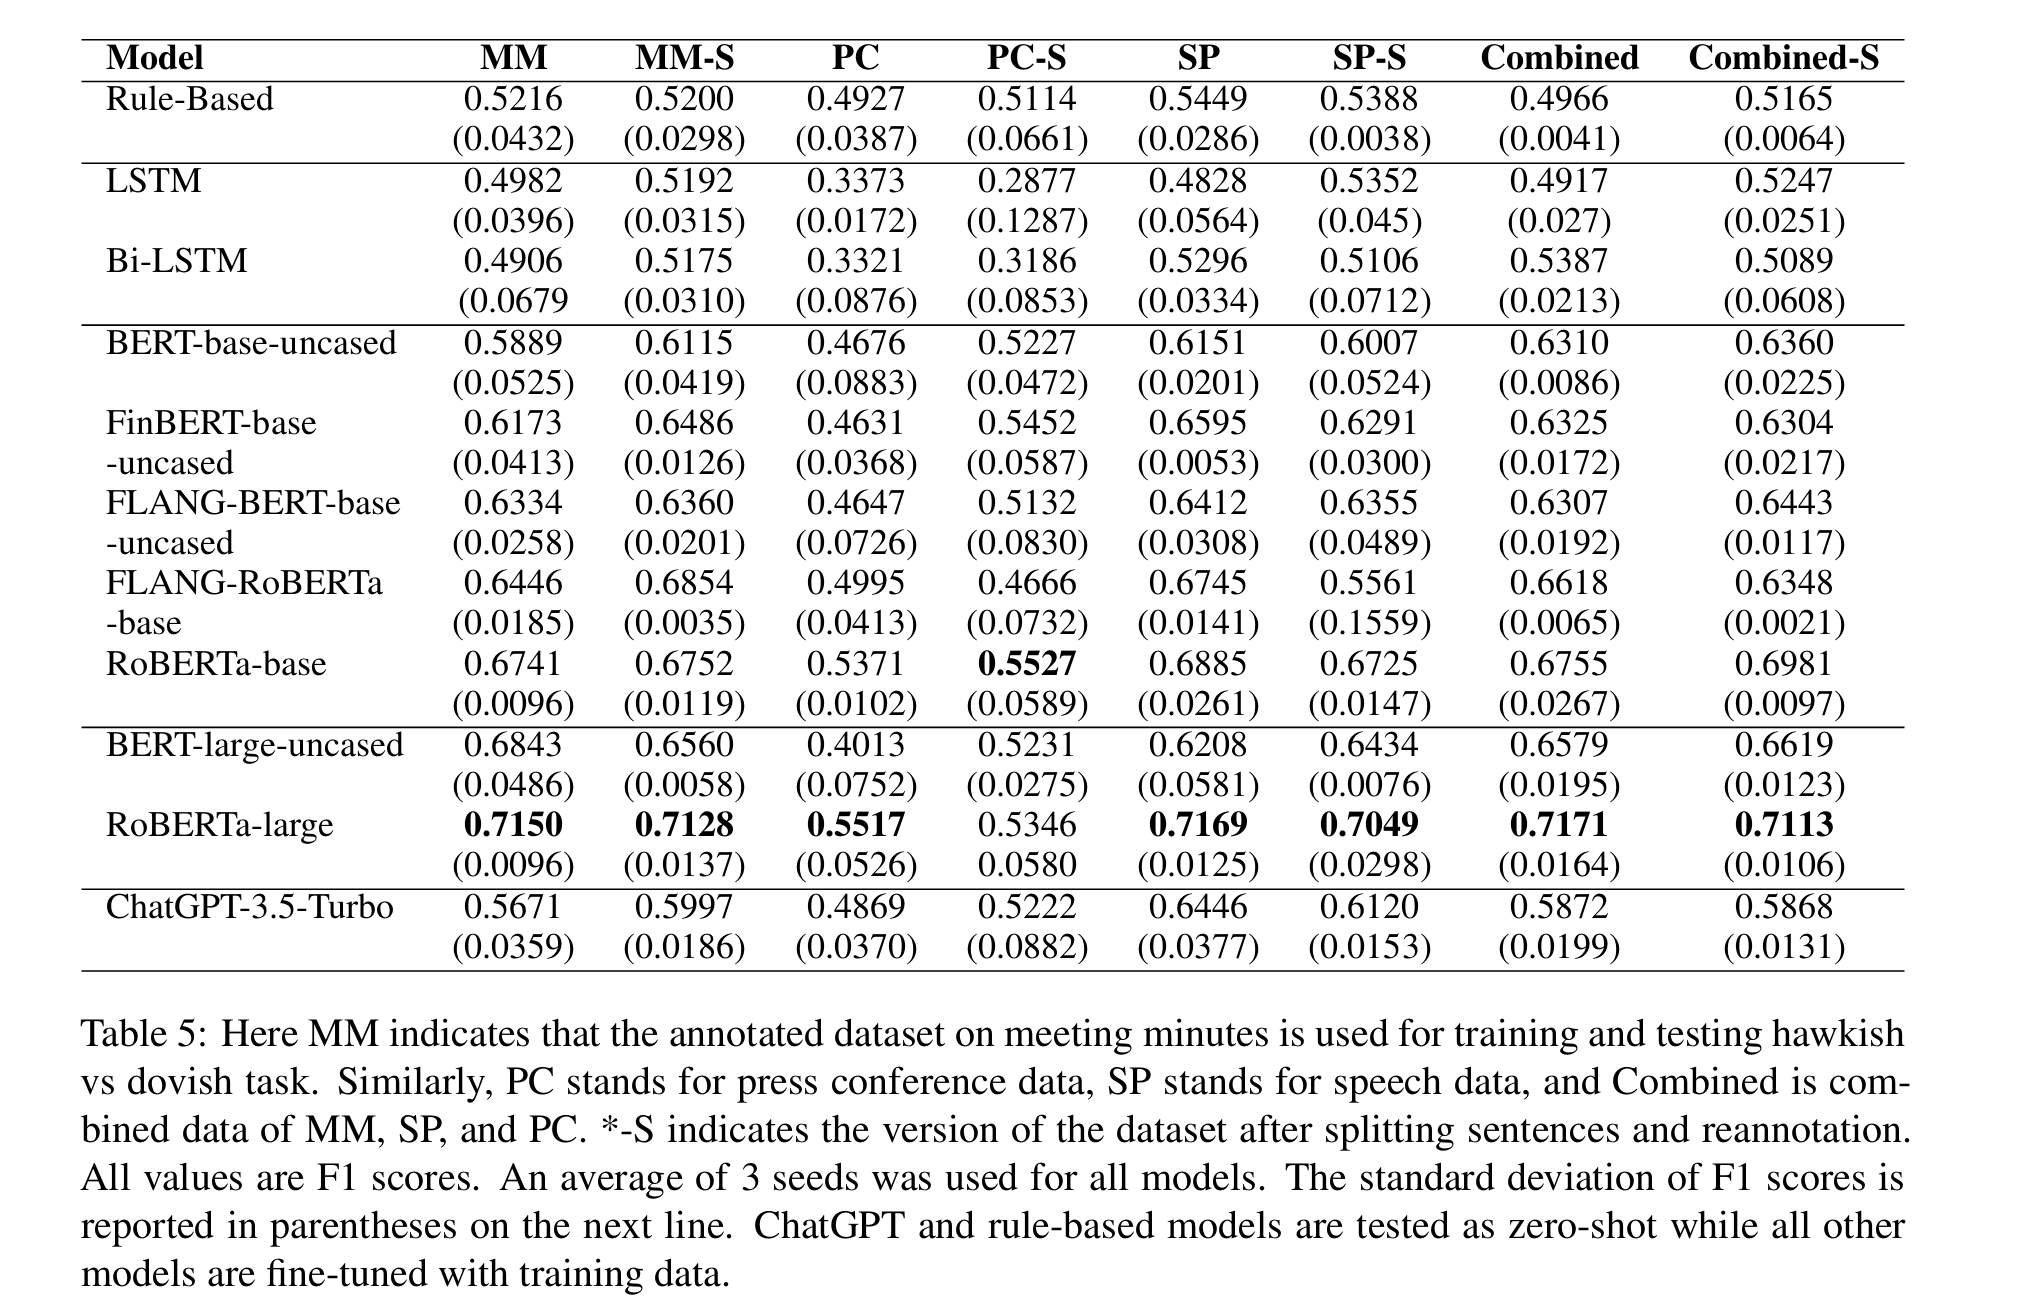

**This project's goal** is to reproduce and build on that BERT-base-uncased baseline.
We fine-tune `bert-base-uncased` on the same Combined training data, which is augmented with
back-translation, synonym replacement, masking, and directional word-swap examples,
tune the learning rate, maximum sequence length, and batch size on a held-out
validation split, and report test performance averaged across the same 3 official
seeds used by Shah et al. (5768, 78516, 944601) for a fair comparison. A key point of this work is ensuring there are no near duplicate leakage from the augmented training data in the validation split
used for model selection, and if the leakage is not addressed, there will be a pitfall that would produce misleadingly optimistic validation scores without any corresponding improvement in true generalisation.

In [ ]:
%pip install -q torch transformers pandas openpyxl scikit-learn matplotlib

In [6]:
import os
import re
import json
import random
import gc
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import AdamW

from transformers import BertTokenizerFast, BertForSequenceClassification

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.feature_extraction.text import TfidfVectorizer

In [7]:
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [81]:
SEED = 5768
SEED2 = 78516
SEED3 = 944601
BATCH_SIZE = 8
LEARNING_RATE = 1e-5
MAX_LENGTH = 256
MAX_EPOCHS = 20
EARLY_STOPPING_PATIENCE = 4
VAL_FRAC = 0.20

SIMILARITY_THRESHOLD = 0.50

MODEL_NAME = "bert-base-uncased"

TRAIN_PATH = "/kaggle/input/datasets/jiangxinyiii/augmented-train-data/lab-manual-combine-train-5768.xlsx"
TEST_PATH = "/kaggle/input/datasets/jiangxinyiii/test-data/lab-manual-combine-test-5768.xlsx"

TRAIN_PATH2 = "/kaggle/input/datasets/jiangxinyiii/augmented-train-data/lab-manual-combine-train-78516.xlsx"
TEST_PATH2 = "/kaggle/input/datasets/jiangxinyiii/test-data/lab-manual-combine-test-78516.xlsx"

TRAIN_PATH3 = "/kaggle/input/datasets/jiangxinyiii/augmented-train-data/lab-manual-combine-train-944601.xlsx"
TEST_PATH3 = "/kaggle/input/datasets/jiangxinyiii/test-data/lab-manual-combine-test-944601.xlsx"

BT_CACHE_PATH = "/kaggle/input/datasets/jiangxinyiii/augmented-train-data/bt_cache.json"

OUTPUT_DIR = "/kaggle/working" if os.path.isdir("/kaggle/working") else "./outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

LABEL_NAMES = ["Dovish", "Hawkish", "Neutral"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("Train file:", TRAIN_PATH)
print("Test file:", TEST_PATH)
print("Train file2:", TRAIN_PATH2)
print("Test file2:", TEST_PATH2)
print("Train file3:", TRAIN_PATH3)
print("Test file3:", TEST_PATH3)
print("Output dir:", OUTPUT_DIR)

Device: cuda
Train file: /kaggle/input/datasets/jiangxinyiii/augmented-train-data/lab-manual-combine-train-5768.xlsx
Test file: /kaggle/input/datasets/jiangxinyiii/test-data/lab-manual-combine-test-5768.xlsx
Train file2: /kaggle/input/datasets/jiangxinyiii/augmented-train-data/lab-manual-combine-train-78516.xlsx
Test file2: /kaggle/input/datasets/jiangxinyiii/test-data/lab-manual-combine-test-78516.xlsx
Train file3: /kaggle/input/datasets/jiangxinyiii/augmented-train-data/lab-manual-combine-train-944601.xlsx
Test file3: /kaggle/input/datasets/jiangxinyiii/test-data/lab-manual-combine-test-944601.xlsx
Output dir: /kaggle/working


In [82]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)
set_seed(SEED2)
set_seed(SEED3)

In [62]:
print("Train file exists:", os.path.exists(TRAIN_PATH))
print("Test file exists:", os.path.exists(TEST_PATH))
print("Train file exists2:", os.path.exists(TRAIN_PATH2))
print("Test file exists2:", os.path.exists(TEST_PATH2))
print("Train file exists3:", os.path.exists(TRAIN_PATH3))
print("Test file exists3:", os.path.exists(TEST_PATH3))
print("BT cache exists:", os.path.exists(BT_CACHE_PATH))

Train file exists: True
Test file exists: True
Train file exists2: True
Test file exists2: True
Train file exists3: True
Test file exists3: True
BT cache exists: True


# **Data Preparation and Leakage Remediation**
## Load the augmented training file and the original test file

In [13]:
train_full_df = pd.read_excel(TRAIN_PATH)
test_df = pd.read_excel(TEST_PATH)

train_full_df = train_full_df.dropna(subset=["sentence", "label"]).copy()
test_df = test_df.dropna(subset=["sentence", "label"]).copy()

train_full_df["sentence"] = train_full_df["sentence"].astype(str)
test_df["sentence"] = test_df["sentence"].astype(str)

train_full_df["label"] = train_full_df["label"].astype(int)
test_df["label"] = test_df["label"].astype(int)

for col in ("augmented", "aug_method"):
    assert col in train_full_df.columns, (
        f"Expected a '{col}' column in the augmented train file - this notebook relies on it "
        f"to tell original rows apart from augmented ones."
    )

train_full_df = train_full_df.reset_index(drop=True)
print("Total rows in augmented train file:", len(train_full_df))
display(train_full_df["aug_method"].value_counts())

Total rows in augmented train file: 5159


aug_method
original               1851
back_translation       1851
synonym_replacement     712
masking                 555
directional_swap        190
Name: count, dtype: int64

In [63]:
train_full_df2 = pd.read_excel(TRAIN_PATH2)
test_df2 = pd.read_excel(TEST_PATH2)

train_full_df2 = train_full_df2.dropna(subset=["sentence", "label"]).copy()
test_df2 = test_df2.dropna(subset=["sentence", "label"]).copy()

train_full_df2["sentence"] = train_full_df2["sentence"].astype(str)
test_df2["sentence"] = test_df2["sentence"].astype(str)

train_full_df2["label"] = train_full_df2["label"].astype(int)
test_df2["label"] = test_df2["label"].astype(int)

for col in ("augmented", "aug_method"):
    assert col in train_full_df2.columns, (
        f"Expected a '{col}' column in the augmented train file - this notebook relies on it "
        f"to tell original rows apart from augmented ones."
    )

train_full_df2 = train_full_df2.reset_index(drop=True)
print("Total rows in augmented train file:", len(train_full_df2))
display(train_full_df2["aug_method"].value_counts())

Total rows in augmented train file: 5181


aug_method
original               1854
back_translation       1854
synonym_replacement     724
masking                 556
directional_swap        193
Name: count, dtype: int64

In [64]:
train_full_df3 = pd.read_excel(TRAIN_PATH3)
test_df3 = pd.read_excel(TEST_PATH3)

train_full_df3 = train_full_df3.dropna(subset=["sentence", "label"]).copy()
test_df3 = test_df3.dropna(subset=["sentence", "label"]).copy()

train_full_df3["sentence"] = train_full_df3["sentence"].astype(str)
test_df3["sentence"] = test_df3["sentence"].astype(str)

train_full_df3["label"] = train_full_df3["label"].astype(int)
test_df3["label"] = test_df3["label"].astype(int)

for col in ("augmented", "aug_method"):
    assert col in train_full_df3.columns, (
        f"Expected a '{col}' column in the augmented train file - this notebook relies on it "
        f"to tell original rows apart from augmented ones."
    )

train_full_df3 = train_full_df3.reset_index(drop=True)
print("Total rows in augmented train file:", len(train_full_df3))
display(train_full_df3["aug_method"].value_counts())

Total rows in augmented train file: 5166


aug_method
original               1853
back_translation       1853
synonym_replacement     714
masking                 556
directional_swap        190
Name: count, dtype: int64

We can get a table as followed:

|Seed|	Original|	Back-translation|	Synonym Replacement|	   Masking|	  Directional Swap|	   Total (augmented train)|
|:-----:|:-----------:|:----------------:|:-------------------:|:--------------:|:-------------------:|:------------------:|
|5768|	  1851|	         1851|	                712|	             555|	        190|	                    5159|
|78516|	  1854|	         1854|	                724|            556|	        193|	                    5181|
|944601|	  1853|	         1853|	                714|	             556|	        190|	                    5166|

The table shows the augmented training set composition across the three official seeds. The number of original deduplicated sentences which are **1851, 1854, 1853** is nearly identical across seeds, as expected since each seed only changes the train and test partitioning of the same underlying corpus, not its total size. The augmentation counts scale consistently with the original pool size and the fixed augmentation ratios defined in the pipeline, which are 100% back-translation, 75% synonym replacement and 20% directional swap on `Hawkish` and `Dovish` sentences, 30% masking overall, confirming that the augmentation procedure behaves deterministically and reproducibly across seeds.

## Recover which original sentence each augmented row came from

`original_pool` is every row with `augmented == 0`, these are the source sentences, no
matching needed. Every other row needs its parent identified.

In [66]:
def _norm(s):
    return re.sub(r"\s+", " ", str(s)).strip().lower()


original_pool = train_full_df[train_full_df["augmented"] == 0].copy()
augmented_rows = train_full_df[train_full_df["augmented"] == 1].copy()
original_pool2 = train_full_df2[train_full_df2["augmented"] == 0].copy()
augmented_rows2 = train_full_df2[train_full_df2["augmented"] == 1].copy()
original_pool3 = train_full_df3[train_full_df3["augmented"] == 0].copy()
augmented_rows3 = train_full_df3[train_full_df3["augmented"] == 1].copy()

original_pool["_norm_sentence"] = original_pool["sentence"].map(_norm)
augmented_rows["_norm_sentence"] = augmented_rows["sentence"].map(_norm)
original_pool2["_norm_sentence"] = original_pool2["sentence"].map(_norm)
augmented_rows2["_norm_sentence"] = augmented_rows2["sentence"].map(_norm)
original_pool3["_norm_sentence"] = original_pool3["sentence"].map(_norm)
augmented_rows3["_norm_sentence"] = augmented_rows3["sentence"].map(_norm)

print("Original (source) sentences:", len(original_pool), len(original_pool2), len(original_pool3))
print("Augmented (derived) rows to match back:", len(augmented_rows), len(augmented_rows2), len(augmented_rows3))

Original (source) sentences: 1851 1854 1853
Augmented (derived) rows to match back: 3308 3327 3313


In [68]:
#Exact recovery for back-translated rows via bt_cache.json
bt_reverse_map = {}
if os.path.exists(BT_CACHE_PATH):
    with open(BT_CACHE_PATH, "r", encoding="utf-8") as f:
        bt_cache = json.load(f)
    for original_sentence, translated_sentence in bt_cache.items():
        bt_reverse_map[_norm(translated_sentence)] = _norm(original_sentence)
    print(f"Loaded bt_cache.json with {len(bt_cache)} entries.")
else:
    print("bt_cache.json not found - back-translated rows will fall back to TF-IDF matching.")

orig_norm_to_idx = dict(zip(original_pool["_norm_sentence"], original_pool.index))
orig_norm_to_idx2 = dict(zip(original_pool2["_norm_sentence"], original_pool2.index))
orig_norm_to_idx3 = dict(zip(original_pool3["_norm_sentence"], original_pool3.index))

parent_idx = pd.Series(index=augmented_rows.index, dtype="object")
match_method = pd.Series(index=augmented_rows.index, dtype="object")
match_score = pd.Series(index=augmented_rows.index, dtype="float64")
parent_idx2 = pd.Series(index=augmented_rows2.index, dtype="object")
match_method2 = pd.Series(index=augmented_rows2.index, dtype="object")
match_score2 = pd.Series(index=augmented_rows2.index, dtype="float64")
parent_idx3 = pd.Series(index=augmented_rows3.index, dtype="object")
match_method3 = pd.Series(index=augmented_rows3.index, dtype="object")
match_score3 = pd.Series(index=augmented_rows3.index, dtype="float64")

is_bt = augmented_rows["aug_method"] == "back_translation"
for i in augmented_rows.index[is_bt]:
    norm_sent = augmented_rows.loc[i, "_norm_sentence"]
    src_norm = bt_reverse_map.get(norm_sent)
    if src_norm is not None and src_norm in orig_norm_to_idx:
        parent_idx.loc[i] = orig_norm_to_idx[src_norm]
        match_method.loc[i] = "bt_cache_exact"
        match_score.loc[i] = 1.0

is_bt2 = augmented_rows2["aug_method"] == "back_translation"
for i in augmented_rows2.index[is_bt2]:
    norm_sent2 = augmented_rows2.loc[i, "_norm_sentence"]
    src_norm2 = bt_reverse_map.get(norm_sent2)
    if src_norm2 is not None and src_norm2 in orig_norm_to_idx2:
        parent_idx2.loc[i] = orig_norm_to_idx2[src_norm2]
        match_method2.loc[i] = "bt_cache_exact"
        match_score2.loc[i] = 1.0

is_bt3 = augmented_rows3["aug_method"] == "back_translation"
for i in augmented_rows3.index[is_bt3]:
    norm_sent3 = augmented_rows3.loc[i, "_norm_sentence"]
    src_norm3 = bt_reverse_map.get(norm_sent3)
    if src_norm3 is not None and src_norm3 in orig_norm_to_idx3:
        parent_idx3.loc[i] = orig_norm_to_idx3[src_norm3]
        match_method3.loc[i] = "bt_cache_exact"
        match_score3.loc[i] = 1.0

n_bt_resolved = match_method.eq("bt_cache_exact").sum()
n_bt_resolved2 = match_method2.eq("bt_cache_exact").sum()
n_bt_resolved3 = match_method3.eq("bt_cache_exact").sum()

print(f"Back-translated rows resolved exactly via bt_cache: {n_bt_resolved} / {is_bt.sum()}, {n_bt_resolved2} / {is_bt2.sum()}, {n_bt_resolved3} / {is_bt3.sum()}")

Loaded bt_cache.json with 2514 entries.
Back-translated rows resolved exactly via bt_cache: 1846 / 1851, 1847 / 1854, 1848 / 1853


In [16]:
# TF-IDF nearest-neighbor recovery for everything else
needs_tfidf = parent_idx.isna()
print("Rows needing TF-IDF matching:", int(needs_tfidf.sum()))

vectorizer = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=1)
orig_matrix = vectorizer.fit_transform(original_pool["sentence"].tolist())

if needs_tfidf.any():
    aug_subset = augmented_rows.loc[needs_tfidf]
    aug_matrix = vectorizer.transform(aug_subset["sentence"].tolist())

    # cosine similarity for L2-normalized TF-IDF vectors == dot product
    sims = aug_matrix @ orig_matrix.T
    sims = sims.toarray()

    best_idx = sims.argmax(axis=1)
    best_score = sims.max(axis=1)

    original_positional_index = original_pool.index.to_numpy()

    for pos, (row_id, best_i, score) in enumerate(
        zip(aug_subset.index, best_idx, best_score)
    ):
        parent_idx.loc[row_id] = original_positional_index[best_i]
        match_method.loc[row_id] = "tfidf_nearest"
        match_score.loc[row_id] = score

augmented_rows["_parent_idx"] = parent_idx
augmented_rows["_match_method"] = match_method
augmented_rows["_match_score"] = match_score

print("\nMatch score distribution:")
print(augmented_rows["_match_score"].describe())

Rows needing TF-IDF matching: 1462

Match score distribution:
count    3308.000000
mean        0.938968
std         0.091103
min         0.000000
25%         0.890458
50%         1.000000
75%         1.000000
max         1.000000
Name: _match_score, dtype: float64


In [71]:
# TF-IDF nearest-neighbor recovery for everything else
needs_tfidf2 = parent_idx2.isna()
print("Rows needing TF-IDF matching:", int(needs_tfidf2.sum()))

vectorizer2 = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=1)
orig_matrix2 = vectorizer2.fit_transform(original_pool2["sentence"].tolist())

if needs_tfidf2.any():
    aug_subset2 = augmented_rows2.loc[needs_tfidf2]
    aug_matrix2 = vectorizer2.transform(aug_subset2["sentence"].tolist())

    # cosine similarity for L2-normalized TF-IDF vectors == dot product
    sims = aug_matrix2 @ orig_matrix2.T
    sims = sims.toarray()

    best_idx2 = sims.argmax(axis=1)
    best_score2 = sims.max(axis=1)

    original_positional_index2 = original_pool2.index.to_numpy()

    for pos, (row_id, best_i, score) in enumerate(
        zip(aug_subset2.index, best_idx2, best_score2)
    ):
        parent_idx2.loc[row_id] = original_positional_index2[best_i]
        match_method2.loc[row_id] = "tfidf_nearest"
        match_score2.loc[row_id] = score

augmented_rows2["_parent_idx"] = parent_idx2
augmented_rows2["_match_method"] = match_method2
augmented_rows2["_match_score"] = match_score2

print("\nMatch score distribution:")
print(augmented_rows2["_match_score"].describe())

Rows needing TF-IDF matching: 1480

Match score distribution:
count    3327.000000
mean        0.938714
std         0.092279
min         0.000000
25%         0.893127
50%         1.000000
75%         1.000000
max         1.000000
Name: _match_score, dtype: float64


In [73]:
# TF-IDF nearest-neighbor recovery for everything else
needs_tfidf3 = parent_idx3.isna()
print("Rows needing TF-IDF matching:", int(needs_tfidf3.sum()))

vectorizer3 = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=1)
orig_matrix3 = vectorizer3.fit_transform(original_pool3["sentence"].tolist())

if needs_tfidf3.any():
    aug_subset3 = augmented_rows3.loc[needs_tfidf3]
    aug_matrix3 = vectorizer3.transform(aug_subset3["sentence"].tolist())

    # cosine similarity for L2-normalized TF-IDF vectors == dot product
    sims = aug_matrix3 @ orig_matrix3.T
    sims = sims.toarray()

    best_idx3 = sims.argmax(axis=1)
    best_score3 = sims.max(axis=1)

    original_positional_index3 = original_pool3.index.to_numpy()

    for pos, (row_id, best_i, score) in enumerate(
        zip(aug_subset3.index, best_idx3, best_score3)
    ):
        parent_idx3.loc[row_id] = original_positional_index3[best_i]
        match_method3.loc[row_id] = "tfidf_nearest"
        match_score3.loc[row_id] = score

augmented_rows3["_parent_idx"] = parent_idx3
augmented_rows3["_match_method"] = match_method3
augmented_rows3["_match_score"] = match_score3

print("\nMatch score distribution:")
print(augmented_rows3["_match_score"].describe())

Rows needing TF-IDF matching: 1465

Match score distribution:
count    3313.000000
mean        0.939504
std         0.089959
min         0.000000
25%         0.889802
50%         1.000000
75%         1.000000
max         1.000000
Name: _match_score, dtype: float64


Hence, we now can know that the parent-sentence recovery mechanism performs consistently and reliably across all three official seeds, with no seed showing anomalous behavior.

In [17]:
resolved = augmented_rows["_match_score"] >= SIMILARITY_THRESHOLD
n_dropped = int((~resolved).sum())

print(f"Resolved with confidence >= {SIMILARITY_THRESHOLD}: {int(resolved.sum())} / {len(augmented_rows)}")
print(f"Dropped as unresolved (kept out of training entirely, to be safe): {n_dropped}")

if n_dropped:
    display(
        augmented_rows.loc[~resolved, ["aug_method", "_match_method", "_match_score"]]
        .groupby(["aug_method", "_match_method"])
        .size()
    )

augmented_rows = augmented_rows.loc[resolved].copy()

Resolved with confidence >= 0.5: 3303 / 3308
Dropped as unresolved (kept out of training entirely, to be safe): 5


aug_method        _match_method
back_translation  tfidf_nearest    5
dtype: int64

In [74]:
resolved2 = augmented_rows2["_match_score"] >= SIMILARITY_THRESHOLD
n_dropped2 = int((~resolved2).sum())

print(f"Resolved with confidence >= {SIMILARITY_THRESHOLD}: {int(resolved2.sum())} / {len(augmented_rows2)}")
print(f"Dropped as unresolved (kept out of training entirely, to be safe): {n_dropped2}")

if n_dropped2:
    display(
        augmented_rows2.loc[~resolved2, ["aug_method", "_match_method", "_match_score"]]
        .groupby(["aug_method", "_match_method"])
        .size()
    )

augmented_rows2 = augmented_rows2.loc[resolved2].copy()

Resolved with confidence >= 0.5: 3321 / 3327
Dropped as unresolved (kept out of training entirely, to be safe): 6


aug_method        _match_method
back_translation  tfidf_nearest    6
dtype: int64

In [75]:
resolved3 = augmented_rows3["_match_score"] >= SIMILARITY_THRESHOLD
n_dropped3 = int((~resolved3).sum())

print(f"Resolved with confidence >= {SIMILARITY_THRESHOLD}: {int(resolved3.sum())} / {len(augmented_rows3)}")
print(f"Dropped as unresolved (kept out of training entirely, to be safe): {n_dropped3}")

if n_dropped3:
    display(
        augmented_rows3.loc[~resolved3, ["aug_method", "_match_method", "_match_score"]]
        .groupby(["aug_method", "_match_method"])
        .size()
    )

augmented_rows3 = augmented_rows3.loc[resolved3].copy()

Resolved with confidence >= 0.5: 3308 / 3313
Dropped as unresolved (kept out of training entirely, to be safe): 5


aug_method        _match_method
back_translation  tfidf_nearest    5
dtype: int64

We can get a table as followed:

|Seed|Resolved(>=0.5)|Dropped|Drop Rate|
|:---:|:-----:|:---:|:----:|
|5768|3303/3308|5|0.15%|
|78516|3321/3327|6|0.18%|
|944601|3308/3313|5|0.15%|

The table shows that TF-IDF matching is 100% reliable for the three augmentation methods that only make small edits, including synonym replacement, masking and directional swap. And the potential uncertainty is just the edge case of "back-translation not found in cache" edge case, which affects just 5-6 rows, which are represented as the drop rate, only 0.15-0.18% of the augmented pool, and can be considered negligible.

## Split ORIGINAL sentences into train/val, then propagate to augmented rows

The split decision is made only on `original_pool` which is stratified by label. Every augmented
row then inherits its parent's split. Validation is filtered to original rows, so it is
never contaminated with augmented content, even if an augmented row's parent happens to fall
in validation, that row is simply excluded, dropped, not moved into validation.

In [18]:
split_rng = random.Random(SEED)
val_positions = set()

for label, group in original_pool.groupby("label"):
    idx = list(group.index)
    split_rng.shuffle(idx)
    n_val = round(len(idx) * VAL_FRAC)
    val_positions.update(idx[:n_val])

original_pool["split"] = ["val" if i in val_positions else "train" for i in original_pool.index]

print(original_pool.groupby(["label", "split"]).size())

label  split
0      train    393
       val       98
1      train    368
       val       92
2      train    720
       val      180
dtype: int64


In [83]:
split_rng2 = random.Random(SEED2)
val_positions2 = set()

for label, group in original_pool2.groupby("label"):
    idx = list(group.index)
    split_rng2.shuffle(idx)
    n_val = round(len(idx) * VAL_FRAC)
    val_positions2.update(idx[:n_val])

original_pool2["split"] = ["val" if i in val_positions2 else "train" for i in original_pool2.index]

print(original_pool2.groupby(["label", "split"]).size())

label  split
0      train    402
       val      100
1      train    371
       val       93
2      train    710
       val      178
dtype: int64


In [84]:
split_rng3 = random.Random(SEED3)
val_positions3 = set()

for label, group in original_pool3.groupby("label"):
    idx = list(group.index)
    split_rng3.shuffle(idx)
    n_val = round(len(idx) * VAL_FRAC)
    val_positions3.update(idx[:n_val])

original_pool3["split"] = ["val" if i in val_positions3 else "train" for i in original_pool3.index]

print(original_pool3.groupby(["label", "split"]).size())

label  split
0      train    390
       val       97
1      train    373
       val       93
2      train    720
       val      180
dtype: int64


We can get a table as followed:

|Seed|	Label 0 val%|	Label 1 val%|	Label 2 val%|
|:---:|:------------:|:--------------:|:-------------:|
|5768|	98/(393+98)=19.96%|	92/(368+92)=20.00%|	180/(720+180)=20.00%|
|78516|	100/(402+100)=19.92%|	93/(371+93)=20.04%|	178/(710+178)=20.05%|
|944601|	97/(390+97)=19.92%|	93/(373+93)=19.96%|	180/(720+180)=20.00%|

The 20% split of these three seeds all implements precisely, and the three results in each label are around 20%, and the error is within 0.1%, which shows that the logic of our splitting has the same performance on different seeds.

In [19]:
parent_split = original_pool["split"].to_dict()
augmented_rows["split"] = augmented_rows["_parent_idx"].map(parent_split)

# Safety net: any augmented row whose parent split is "val" is dropped from
# training rather than kept - augmented data must never enter validation.
augmented_train_rows = augmented_rows[augmented_rows["split"] == "train"].copy()
n_dropped_val_parent = int((augmented_rows["split"] == "val").sum())
print(f"Augmented rows whose parent is in validation (dropped, not used anywhere): {n_dropped_val_parent}")

train_df = pd.concat(
    [
        original_pool[original_pool["split"] == "train"][["sentence", "label"]],
        augmented_train_rows[["sentence", "label"]],
    ],
    ignore_index=True,
)
val_df = original_pool[original_pool["split"] == "val"][["sentence", "label"]].reset_index(drop=True)

print("Final train rows (original + augmented):", len(train_df))
print("Final val rows (original only):", len(val_df))

Augmented rows whose parent is in validation (dropped, not used anywhere): 664
Final train rows (original + augmented): 4120
Final val rows (original only): 370


In [87]:
parent_split2 = original_pool2["split"].to_dict()
augmented_rows2["split"] = augmented_rows2["_parent_idx"].map(parent_split2)

# Safety net: any augmented row whose parent split is "val" is dropped from
# training rather than kept - augmented data must never enter validation.
augmented_train_rows2 = augmented_rows2[augmented_rows2["split"] == "train"].copy()
n_dropped_val_parent2 = int((augmented_rows2["split"] == "val").sum())
print(f"Augmented rows whose parent is in validation (dropped, not used anywhere): {n_dropped_val_parent2}")

train_df2 = pd.concat(
    [
        original_pool2[original_pool2["split"] == "train"][["sentence", "label"]],
        augmented_train_rows2[["sentence", "label"]],
    ],
    ignore_index=True,
)
val_df2 = original_pool2[original_pool2["split"] == "val"][["sentence", "label"]].reset_index(drop=True)

print("Final train rows (original + augmented):", len(train_df2))
print("Final val rows (original only):", len(val_df2))

Augmented rows whose parent is in validation (dropped, not used anywhere): 664
Final train rows (original + augmented): 4140
Final val rows (original only): 371


In [88]:
parent_split3 = original_pool3["split"].to_dict()
augmented_rows3["split"] = augmented_rows3["_parent_idx"].map(parent_split3)

# Safety net: any augmented row whose parent split is "val" is dropped from
# training rather than kept - augmented data must never enter validation.
augmented_train_rows3 = augmented_rows3[augmented_rows3["split"] == "train"].copy()
n_dropped_val_parent3 = int((augmented_rows3["split"] == "val").sum())
print(f"Augmented rows whose parent is in validation (dropped, not used anywhere): {n_dropped_val_parent3}")

train_df3 = pd.concat(
    [
        original_pool3[original_pool3["split"] == "train"][["sentence", "label"]],
        augmented_train_rows3[["sentence", "label"]],
    ],
    ignore_index=True,
)
val_df3 = original_pool3[original_pool3["split"] == "val"][["sentence", "label"]].reset_index(drop=True)

print("Final train rows (original + augmented):", len(train_df3))
print("Final val rows (original only):", len(val_df3))

Augmented rows whose parent is in validation (dropped, not used anywhere): 655
Final train rows (original + augmented): 4136
Final val rows (original only): 370


We can get a table as followed:

|Seed|	Resolved Augmented Row|	Dropped|	Drop Rate|
|:---:|:---------:|:--------:|:--------:|
|5768|	3303|	664|	20.1%|
|78516|	3321|	664|	20.0%|
|944601|	3308|	655|	19.8%|

Because the original sentences were assigned to the validation split at a 20% rate, and the "parent" of each augmented row is drawn roughly uniformly from the whole pool of original sentences, then according to the probability, we can know that about 20% of augmented rows will happen to have a parent that landed in validation. This set of numbers precisely confirms that the logic of whole parent recovery and split propagation is working as expected.

We can have a summary table as followed:

|Seed|	Original Train|	Original val|	Remained Train|	Final Train in Total|	Final val|
|:---:|:------------:|:-------------:|:----------:|:---------:|:----:|
|5768|	1481|	370|	2639|	4120|	370|
|78516|	1483|	371	|2657|	4140|	371|
|944601|	1483|	370	|2653|	4136|	370|

These final train sets of the three seeds all have a stable scale between 4120 and 4140, and validation is also stable between 370 and 371, only with few dozens, which shows that the whole data processing is quite consistent in the three seeds.

## Leakage sanity check

Confirms zero normalized-sentence overlap between train / val / test. This is the check that
would have caught the original leakage problem.

In [20]:
train_norm = set(train_df["sentence"].map(_norm))
val_norm = set(val_df["sentence"].map(_norm))
test_norm = set(test_df["sentence"].map(_norm))

train_val_overlap = train_norm & val_norm
train_test_overlap = train_norm & test_norm
val_test_overlap = val_norm & test_norm

print("train & val overlap:", len(train_val_overlap))
print("train & test overlap:", len(train_test_overlap))
print("val & test overlap:", len(val_test_overlap))

assert len(train_val_overlap) == 0, "Leakage detected between train and val!"
assert len(train_test_overlap) == 0, "Leakage detected between train and test!"
assert len(val_test_overlap) == 0, "Leakage detected between val and test!"

print("\nNo exact-duplicate leakage detected between train / val / test.")
print("(Near-duplicate augmented rows have also been kept out of validation by construction.)")

train & val overlap: 0
train & test overlap: 0
val & test overlap: 0

No exact-duplicate leakage detected between train / val / test.
(Near-duplicate augmented rows have also been kept out of validation by construction.)


In [89]:
train_norm2 = set(train_df2["sentence"].map(_norm))
val_norm2 = set(val_df2["sentence"].map(_norm))
test_norm2 = set(test_df2["sentence"].map(_norm))

train_val_overlap2 = train_norm2 & val_norm2
train_test_overlap2 = train_norm2 & test_norm2
val_test_overlap2 = val_norm2 & test_norm2

print("train & val overlap:", len(train_val_overlap2))
print("train & test overlap:", len(train_test_overlap2))
print("val & test overlap:", len(val_test_overlap2))

assert len(train_val_overlap2) == 0, "Leakage detected between train and val!"
assert len(train_test_overlap2) == 0, "Leakage detected between train and test!"
assert len(val_test_overlap2) == 0, "Leakage detected between val and test!"

print("\nNo exact-duplicate leakage detected between train / val / test.")
print("(Near-duplicate augmented rows have also been kept out of validation by construction.)")

train & val overlap: 0
train & test overlap: 0
val & test overlap: 0

No exact-duplicate leakage detected between train / val / test.
(Near-duplicate augmented rows have also been kept out of validation by construction.)


In [91]:
train_norm3 = set(train_df3["sentence"].map(_norm))
val_norm3 = set(val_df3["sentence"].map(_norm))
test_norm3 = set(test_df3["sentence"].map(_norm))

train_val_overlap3 = train_norm3 & val_norm3
train_test_overlap3 = train_norm3 & test_norm3
val_test_overlap3 = val_norm3 & test_norm3

print("train & val overlap:", len(train_val_overlap3))
print("train & test overlap:", len(train_test_overlap3))
print("val & test overlap:", len(val_test_overlap3))

assert len(train_val_overlap3) == 0, "Leakage detected between train and val!"
assert len(train_test_overlap3) == 0, "Leakage detected between train and test!"
assert len(val_test_overlap3) == 0, "Leakage detected between val and test!"

print("\nNo exact-duplicate leakage detected between train / val / test.")
print("(Near-duplicate augmented rows have also been kept out of validation by construction.)")

train & val overlap: 0
train & test overlap: 0
val & test overlap: 0

No exact-duplicate leakage detected between train / val / test.
(Near-duplicate augmented rows have also been kept out of validation by construction.)


To verify that the leakage remediation procedure generalizes beyond a single data split, we repeated the exact duplicate overlap check across all three official seeds, which are 5768, 78516, 944601.

In every case, the normalized sentence overlap between train and validation, train and test, and validation and test was exactly zero, which confirms that no original sentence nor any of its augmented derivatives crosses partition boundaries. This consistency across three independently partitioned seeds gives strong evidence that the leakage fix is a property of the methodology itself, rather than a coincidence specific to one train and test split.

# **Exploratory Data Analysis**

`train_df` includes augmented rows.

`val_df` and `test_df` are both original, unaugmented data, so they reflect the true class balance of the annotated corpus.

In [93]:
def show_label_distribution(df: pd.DataFrame, name: str) -> pd.DataFrame:
    counts = df["label"].value_counts().sort_index()
    percentages = counts / counts.sum() * 100

    result = pd.DataFrame({
        "Label ID": counts.index,
        "Label Name": [LABEL_NAMES[i] for i in counts.index],
        "Count": counts.values,
        "Percentage": percentages.values
    })

    print(name)
    display(result)

    return result


train_distribution = show_label_distribution(train_df, "Training Set (incl. augmented)")
val_distribution = show_label_distribution(val_df, "Validation Set (original only)")
test_distribution = show_label_distribution(test_df, "Test Set")

train_distribution2 = show_label_distribution(train_df2, "Training Set (incl. augmented)")
val_distribution2 = show_label_distribution(val_df2, "Validation Set (original only)")
test_distribution2 = show_label_distribution(test_df2, "Test Set")

train_distribution3 = show_label_distribution(train_df3, "Training Set (incl. augmented)")
val_distribution3 = show_label_distribution(val_df3, "Validation Set (original only)")
test_distribution3 = show_label_distribution(test_df3, "Test Set")

Training Set (incl. augmented)


,Label ID,Label Name,Count,Percentage
0,0,Dovish,1283,31.140777
1,1,Hawkish,1174,28.495146
2,2,Neutral,1663,40.364078


Validation Set (original only)


,Label ID,Label Name,Count,Percentage
0,0,Dovish,98,26.486486
1,1,Hawkish,92,24.864865
2,2,Neutral,180,48.648649


Test Set


...

,Label ID,Label Name,Count,Percentage
0,0,Dovish,1244,30.077369
1,1,Hawkish,1232,29.787234
2,2,Neutral,1660,40.135397


Validation Set (original only)


,Label ID,Label Name,Count,Percentage
0,0,Dovish,97,26.216216
1,1,Hawkish,93,25.135135
2,2,Neutral,180,48.648649


Test Set


,Label ID,Label Name,Count,Percentage
0,0,Dovish,128,26.890756
1,1,Hawkish,120,25.210084
2,2,Neutral,228,47.899160


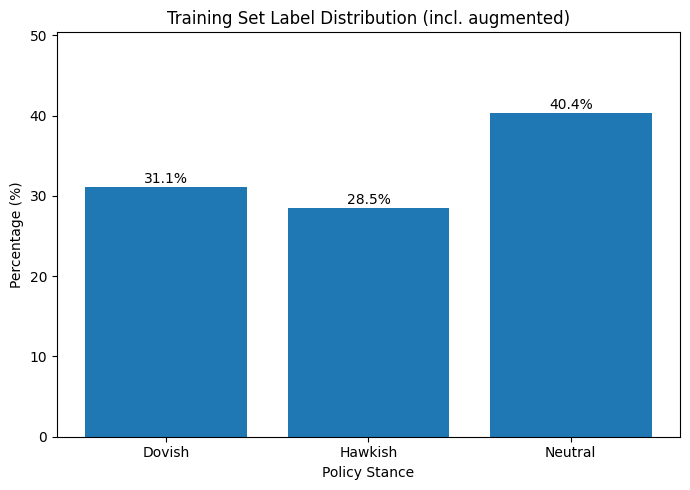

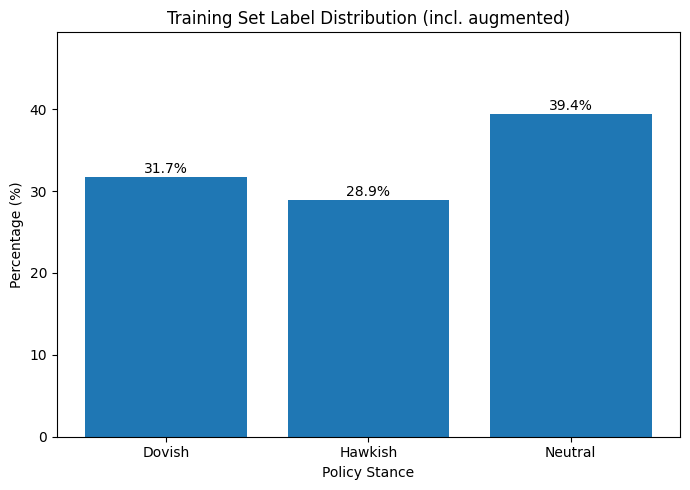

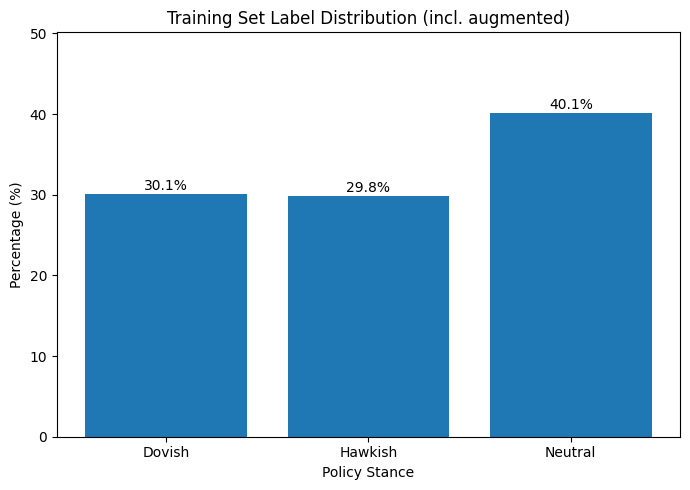

In [98]:
plt.figure(figsize=(7, 5))

bars = plt.bar(train_distribution["Label Name"], train_distribution["Percentage"])

plt.title("Training Set Label Distribution (incl. augmented)")
plt.xlabel("Policy Stance")
plt.ylabel("Percentage (%)")
plt.ylim(0, train_distribution["Percentage"].max() + 10)

for bar, percentage in zip(bars, train_distribution["Percentage"]):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
              f"{percentage:.1f}%", ha="center")

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))

bars2 = plt.bar(train_distribution2["Label Name"], train_distribution2["Percentage"])

plt.title("Training Set Label Distribution (incl. augmented)")
plt.xlabel("Policy Stance")
plt.ylabel("Percentage (%)")
plt.ylim(0, train_distribution2["Percentage"].max() + 10)

for bar, percentage in zip(bars2, train_distribution2["Percentage"]):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
              f"{percentage:.1f}%", ha="center")

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))

bars3 = plt.bar(train_distribution3["Label Name"], train_distribution3["Percentage"])

plt.title("Training Set Label Distribution (incl. augmented)")
plt.xlabel("Policy Stance")
plt.ylabel("Percentage (%)")
plt.ylim(0, train_distribution3["Percentage"].max() + 10)

for bar, percentage in zip(bars3, train_distribution3["Percentage"]):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
              f"{percentage:.1f}%", ha="center")

plt.tight_layout()
plt.show()

Right now, we can have some key findings:

1. Among the three seeds, the proportion of Validation(Val), Test and Neutral all remain stable at **47-50%**, the proportion of `Dovish` and `Hawkish` both remain stable at **24-27%**, which is expected, because Val and Test are both original data without being augmented, which shows that they have real distribution of classification, not affected by augmented data.

2. It is noticeable that train including augmented is more balanced than val and test, and it is a direct consequence of how the augmentation strategy is designed.

    `Neutral` drops from about 48% down to about 40% in train, while `Dovish` and `Hawkish` correspondingly rise from about 25-27% to about 28-32%. And the logic in `augment_dataset.py` can explain:

    Synonym replacement (75%) and directional swap (20%) are only applied to the `Hawkish` and `Dovish` minority classes, and `Neutral` does not take part in either of these two augmentation methods.

    Masking (30%) and back-translation (100%) are applied uniformly across all classes, without favoring any particular one.

    This means `Hawkish` and `Dovish` effectively receive an "extra" augmentation multiplier relative to `Neutral`. The side effect is that the augmented training set ends up more balanced than the original annotated corpus, even though the augmentation script was not explicitly designed to address class imbalance, it ends up mitigating it as a byproduct.

In [100]:
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

print("Tokenizer loaded:", MODEL_NAME)
print("Vocabulary size:", tokenizer.vocab_size)

tokenizer2 = BertTokenizerFast.from_pretrained(MODEL_NAME)

print("Tokenizer loaded:", MODEL_NAME)
print("Vocabulary size:", tokenizer2.vocab_size)

tokenizer3 = BertTokenizerFast.from_pretrained(MODEL_NAME)

print("Tokenizer loaded:", MODEL_NAME)
print("Vocabulary size:", tokenizer3.vocab_size)

Tokenizer loaded: bert-base-uncased
Vocabulary size: 30522
Tokenizer loaded: bert-base-uncased
Vocabulary size: 30522
Tokenizer loaded: bert-base-uncased
Vocabulary size: 30522


In [101]:
train_token_lengths = train_df["sentence"].apply(
    lambda sentence: len(tokenizer(sentence, add_special_tokens=True, truncation=False)["input_ids"])
)

print(train_token_lengths.describe())

for limit in [64, 128, 256, 512]:
    count = (train_token_lengths > limit).sum()
    percentage = (train_token_lengths > limit).mean() * 100
    print(f"Longer than {limit}: {count} sentences ({percentage:.2f}%)")



train_token_lengths2 = train_df2["sentence"].apply(
    lambda sentence: len(tokenizer2(sentence, add_special_tokens=True, truncation=False)["input_ids"])
)

print(train_token_lengths2.describe())

for limit in [64, 128, 256, 512]:
    count = (train_token_lengths2 > limit).sum()
    percentage = (train_token_lengths2 > limit).mean() * 100
    print(f"Longer than {limit}: {count} sentences ({percentage:.2f}%)")



train_token_lengths3 = train_df3["sentence"].apply(
    lambda sentence: len(tokenizer3(sentence, add_special_tokens=True, truncation=False)["input_ids"])
)

print(train_token_lengths3.describe())

for limit in [64, 128, 256, 512]:
    count = (train_token_lengths3 > limit).sum()
    percentage = (train_token_lengths3 > limit).mean() * 100
    print(f"Longer than {limit}: {count} sentences ({percentage:.2f}%)")

count    4120.000000
mean       38.923058
std        19.798098
min         5.000000
25%        26.000000
50%        36.000000
75%        47.000000
max       512.000000
Name: sentence, dtype: float64
Longer than 64: 318 sentences (7.72%)
Longer than 128: 14 sentences (0.34%)
Longer than 256: 1 sentences (0.02%)
Longer than 512: 0 sentences (0.00%)
count    4140.000000
mean       39.137198
std        20.322550
min         8.000000
25%        27.000000
50%        36.000000
75%        47.000000
max       512.000000
Name: sentence, dtype: float64
Longer than 64: 299 sentences (7.22%)
Longer than 128: 19 sentences (0.46%)
Longer than 256: 1 sentences (0.02%)
Longer than 512: 0 sentences (0.00%)
count    4136.000000
mean       39.448985
std        20.204572
min         8.000000
25%        27.000000
50%        36.000000
75%        47.000000
max       512.000000
Name: sentence, dtype: float64
Longer than 64: 318 sentences (7.69%)
Longer than 128: 22 sentences (0.53%)
Longer than 256: 1 sentence

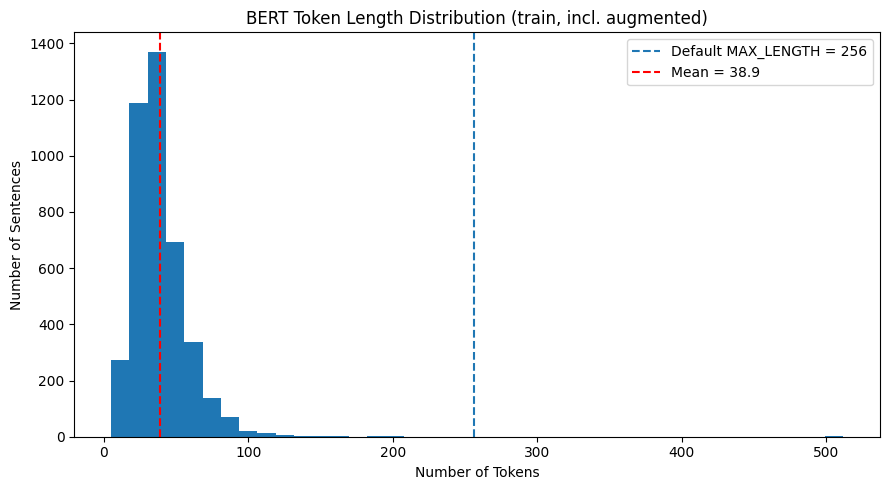

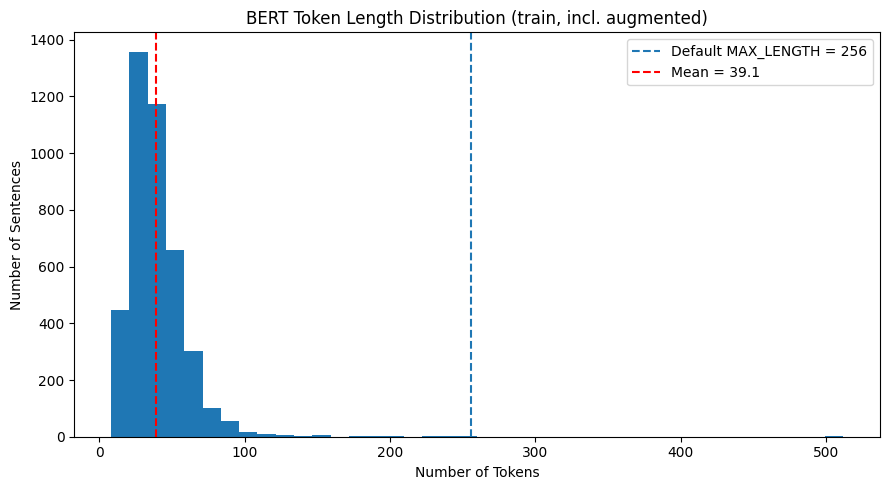

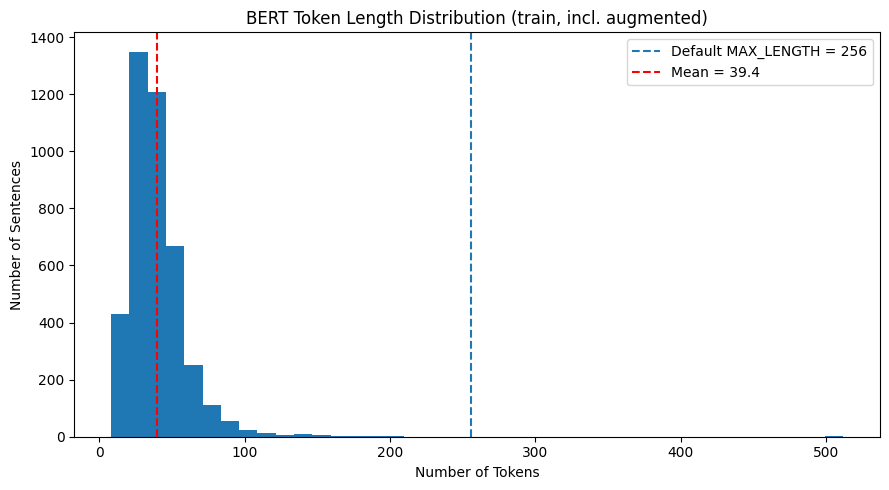

In [102]:
plt.figure(figsize=(9, 5))

plt.hist(train_token_lengths, bins=40)
plt.axvline(MAX_LENGTH, linestyle="--", label=f"Default MAX_LENGTH = {MAX_LENGTH}")
plt.axvline(train_token_lengths.mean(), color="red", linestyle="--",
            label=f"Mean = {train_token_lengths.mean():.1f}")
plt.title("BERT Token Length Distribution (train, incl. augmented)")
plt.xlabel("Number of Tokens")
plt.ylabel("Number of Sentences")
plt.legend()
plt.tight_layout()
plt.show()



plt.figure(figsize=(9, 5))

plt.hist(train_token_lengths2, bins=40)
plt.axvline(MAX_LENGTH, linestyle="--", label=f"Default MAX_LENGTH = {MAX_LENGTH}")
plt.axvline(train_token_lengths2.mean(), color="red", linestyle="--",
            label=f"Mean = {train_token_lengths2.mean():.1f}")
plt.title("BERT Token Length Distribution (train, incl. augmented)")
plt.xlabel("Number of Tokens")
plt.ylabel("Number of Sentences")
plt.legend()
plt.tight_layout()
plt.show()



plt.figure(figsize=(9, 5))

plt.hist(train_token_lengths3, bins=40)
plt.axvline(MAX_LENGTH, linestyle="--", label=f"Default MAX_LENGTH = {MAX_LENGTH}")
plt.axvline(train_token_lengths3.mean(), color="red", linestyle="--",
            label=f"Mean = {train_token_lengths3.mean():.1f}")
plt.title("BERT Token Length Distribution (train, incl. augmented)")
plt.xlabel("Number of Tokens")
plt.ylabel("Number of Sentences")
plt.legend()
plt.tight_layout()
plt.show()

Token length distributions are nearly identical across all three seeds, mean 38.9, 39.1, 39.4 tokens, with the vast majority of sentences under 100 tokens and a long, thin tail extending toward 500 tokens, namely a small number of back translated outliers. This consistency confirms that the choice of `max_length=128`, validated experimentally on seed 5768, is not specific to that seed's particular train and validation split, and generalizes safely to seeds 78516 and 944601 as well.

Across all three seeds, **fewer than 0.6%** of sentences exceed 128 tokens, 0.34%, 0.46%, 0.53% for seeds 5768, 78516, 944601 respectively, and virtually none exceed 256 tokens, only a single sentence in each seed, 0.02%. This confirms that truncating at `max_length=128` discards a negligible fraction of information across all three data splits, supporting the choice of 128 over 256 as both more efficient and sufficient for this task.

## Shared tokenization / DataLoader builder

This single function is reused for **every** experiment below. It tokenizes `train_df`,
`val_df`, and `test_df` at a given `max_length` - it never re-splits rows, so the leak-free
train/val boundary established above is preserved through every experiment stage.

In [103]:
def build_dataloaders(train_df, val_df, test_df, tokenizer, max_length, batch_size, seed):
    def encode(df):
        enc = tokenizer(
            df["sentence"].tolist(),
            add_special_tokens=True,
            padding="max_length",
            truncation=True,
            max_length=max_length,
            return_attention_mask=True,
            return_tensors="pt",
        )
        labels = torch.tensor(df["label"].to_numpy(), dtype=torch.long)
        return TensorDataset(enc["input_ids"], enc["attention_mask"], labels)

    train_dataset = encode(train_df)
    val_dataset = encode(val_df)
    test_dataset = encode(test_df)

    gen = torch.Generator().manual_seed(seed)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=gen)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader


train_loader, val_loader, test_loader = build_dataloaders(
    train_df, val_df, test_df, tokenizer, MAX_LENGTH, BATCH_SIZE, SEED
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))



train_loader2, val_loader2, test_loader2 = build_dataloaders(
    train_df2, val_df2, test_df2, tokenizer2, MAX_LENGTH, BATCH_SIZE, SEED2
)

print("Train batches:", len(train_loader2))
print("Val batches:", len(val_loader2))
print("Test batches:", len(test_loader2))



train_loader3, val_loader3, test_loader3 = build_dataloaders(
    train_df3, val_df3, test_df3, tokenizer3, MAX_LENGTH, BATCH_SIZE, SEED3
)

print("Train batches:", len(train_loader3))
print("Val batches:", len(val_loader3))
print("Test batches:", len(test_loader3))

Train batches: 515
Val batches: 47
Test batches: 60
Train batches: 518
Val batches: 47
Test batches: 60
Train batches: 517
Val batches: 47
Test batches: 60


We can know that dataLoader batch counts are consistent with expected train batches across all three seeds, confirming no data was lost or duplicated during the tokenization and loading step.

# **Fine-tune**

In [25]:
def evaluate_model(model, data_loader, device):
    model.eval()

    total_loss = 0.0
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for input_ids, attention_mask, labels in data_loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            logits = outputs.logits
            predictions = torch.argmax(logits, dim=1)

            total_loss += loss.item() * input_ids.size(0)
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())

    average_loss = total_loss / len(data_loader.dataset)
    accuracy = accuracy_score(all_labels, all_predictions)
    weighted_f1 = f1_score(all_labels, all_predictions, average="weighted", zero_division=0)
    macro_f1 = f1_score(all_labels, all_predictions, average="macro", zero_division=0)

    return {
        "loss": average_loss,
        "accuracy": accuracy,
        "weighted_f1": weighted_f1,
        "macro_f1": macro_f1,
        "labels": np.array(all_labels),
        "predictions": np.array(all_predictions),
    }

In [26]:
def train_bert_experiment(
    learning_rate,
    train_loader,
    validation_loader,
    test_loader,
    seed=SEED,
    max_epochs=20,
    early_stopping_patience=4,
    extra_result_fields=None,
):
    """Fine-tune a fresh bert-base-uncased model with one config.

    Model selection (checkpoint + early stopping) is based ONLY on validation
    weighted F1. Test metrics are computed once, after selection, purely for
    reporting - they never influence which epoch/checkpoint is kept.
    """
    set_seed(seed)

    model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3).to(device)
    optimizer = AdamW(model.parameters(), lr=learning_rate)

    history = []
    best_validation_f1 = -1.0
    best_model_state = None
    best_epoch = None
    epochs_without_improvement = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        total_training_loss = 0.0

        for input_ids, attention_mask, labels in train_loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_training_loss += loss.item() * input_ids.size(0)

        average_training_loss = total_training_loss / len(train_loader.dataset)
        validation_metrics = evaluate_model(model, validation_loader, device)

        history.append({
            "learning_rate": learning_rate,
            "epoch": epoch,
            "train_loss": average_training_loss,
            "val_loss": validation_metrics["loss"],
            "val_accuracy": validation_metrics["accuracy"],
            "val_weighted_f1": validation_metrics["weighted_f1"],
            "val_macro_f1": validation_metrics["macro_f1"],
        })

        print(
            f"LR {learning_rate:.0e} | Epoch {epoch:02d} | "
            f"Train Loss: {average_training_loss:.4f} | "
            f"Val Loss: {validation_metrics['loss']:.4f} | "
            f"Val Accuracy: {validation_metrics['accuracy']:.4f} | "
            f"Val Weighted F1: {validation_metrics['weighted_f1']:.4f}"
        )

        current_f1 = validation_metrics["weighted_f1"]
        if current_f1 > best_validation_f1:
            best_validation_f1 = current_f1
            best_model_state = deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= early_stopping_patience:
            print(f"Early stopping for LR {learning_rate:.0e} after epoch {epoch}.")
            break

    if best_model_state is None:
        raise RuntimeError(f"No checkpoint was saved for learning rate {learning_rate}.")

    model.load_state_dict(best_model_state)

    # Test is evaluated only AFTER validation-based model selection is finished.
    test_metrics = evaluate_model(model, test_loader, device)

    result = {
        "Model": MODEL_NAME,
        "Seed": seed,
        "Learning Rate": learning_rate,
        "Best Epoch": best_epoch,
        "Best Validation Weighted F1": best_validation_f1,
        "Test Loss": test_metrics["loss"],
        "Test Accuracy": test_metrics["accuracy"],
        "Test Weighted F1": test_metrics["weighted_f1"],
        "Test Macro F1": test_metrics["macro_f1"],
    }
    if extra_result_fields:
        result.update(extra_result_fields)

    history_df = pd.DataFrame(history)

    del model, optimizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result, history_df, best_model_state

## Parameter 1: Fine-tune: Learning rate sweep

Uses the shared `train_loader` / `val_loader` / `test_loader` built above at the default
`MAX_LENGTH` / `BATCH_SIZE`. Model selection is by validation weighted F1 only.

In [32]:
LEARNING_RATES = [1e-5, 2e-5, 3e-5, 5e-5]

lr_results = []
lr_histories = {}
lr_checkpoints = {}

for learning_rate in LEARNING_RATES:
    print("\n" + "=" * 70)
    print(f"Starting experiment: learning rate = {learning_rate:.0e}")
    print("=" * 70)

    result, history_df, checkpoint = train_bert_experiment(
        learning_rate=learning_rate,
        train_loader=train_loader,
        validation_loader=val_loader,
        test_loader=test_loader,
        seed=SEED,
        max_epochs=8,
        early_stopping_patience=2,
    )

    lr_results.append(result)
    lr_histories[learning_rate] = history_df
    lr_checkpoints[learning_rate] = checkpoint

lr_results_df = pd.DataFrame(lr_results).sort_values(
    by="Best Validation Weighted F1", ascending=False
).reset_index(drop=True)

display(lr_results_df)


Starting experiment: learning rate = 1e-05


LR 1e-05 | Epoch 01 | Train Loss: 0.9356 | Val Loss: 0.9507 | Val Accuracy: 0.5243 | Val Weighted F1: 0.5203
LR 1e-05 | Epoch 02 | Train Loss: 0.5948 | Val Loss: 1.0996 | Val Accuracy: 0.6108 | Val Weighted F1: 0.6080
LR 1e-05 | Epoch 03 | Train Loss: 0.3251 | Val Loss: 1.6016 | Val Accuracy: 0.6378 | Val Weighted F1: 0.6248
LR 1e-05 | Epoch 04 | Train Loss: 0.2013 | Val Loss: 2.0479 | Val Accuracy: 0.6108 | Val Weighted F1: 0.6141
LR 1e-05 | Epoch 05 | Train Loss: 0.1112 | Val Loss: 2.4716 | Val Accuracy: 0.6081 | Val Weighted F1: 0.6058
Early stopping for LR 1e-05 after epoch 5.

Starting experiment: learning rate = 2e-05


LR 2e-05 | Epoch 01 | Train Loss: 0.8867 | Val Loss: 0.8946 | Val Accuracy: 0.6324 | Val Weighted F1: 0.6194
LR 2e-05 | Epoch 02 | Train Loss: 0.4389 | Val Loss: 1.2533 | Val Accuracy: 0.6514 | Val Weighted F1: 0.6512
LR 2e-05 | Epoch 03 | Train Loss: 0.1971 | Val Loss: 2.2296 | Val Accuracy: 0.6216 | Val Weighted F1: 0.6201
LR 2e-05 | Epoch 04 | Train Loss: 0.1096 | Val Loss: 2.7150 | Val Accuracy: 0.6081 | Val Weighted F1: 0.6099
Early stopping for LR 2e-05 after epoch 4.

Starting experiment: learning rate = 3e-05


LR 3e-05 | Epoch 01 | Train Loss: 0.9039 | Val Loss: 1.0112 | Val Accuracy: 0.5865 | Val Weighted F1: 0.5911
LR 3e-05 | Epoch 02 | Train Loss: 0.4424 | Val Loss: 1.7290 | Val Accuracy: 0.5838 | Val Weighted F1: 0.5821
LR 3e-05 | Epoch 03 | Train Loss: 0.2288 | Val Loss: 2.3230 | Val Accuracy: 0.6162 | Val Weighted F1: 0.6176
LR 3e-05 | Epoch 04 | Train Loss: 0.1267 | Val Loss: 2.6258 | Val Accuracy: 0.6135 | Val Weighted F1: 0.6151
LR 3e-05 | Epoch 05 | Train Loss: 0.0936 | Val Loss: 2.7691 | Val Accuracy: 0.6135 | Val Weighted F1: 0.6072
Early stopping for LR 3e-05 after epoch 5.

Starting experiment: learning rate = 5e-05


LR 5e-05 | Epoch 01 | Train Loss: 0.8828 | Val Loss: 1.0365 | Val Accuracy: 0.6000 | Val Weighted F1: 0.6033
LR 5e-05 | Epoch 02 | Train Loss: 0.4706 | Val Loss: 1.6248 | Val Accuracy: 0.5892 | Val Weighted F1: 0.5660
LR 5e-05 | Epoch 03 | Train Loss: 0.2484 | Val Loss: 2.3338 | Val Accuracy: 0.6000 | Val Weighted F1: 0.5976
Early stopping for LR 5e-05 after epoch 3.


,Model,Seed,Learning Rate,Best Epoch,Best Validation Weighted F1,Test Loss,Test Accuracy,Test Weighted F1,Test Macro F1
0,bert-base-uncased,5768,0.00002,2,0.651171,1.226784,0.626050,0.629358,0.612634
1,bert-base-uncased,5768,0.00001,3,0.624782,1.617930,0.617647,0.598693,0.568469
2,bert-base-uncased,5768,0.00003,3,0.617601,2.044454,0.638655,0.637890,0.620746
3,bert-base-uncased,5768,0.00005,1,0.603326,0.931741,0.611345,0.607314,0.585068


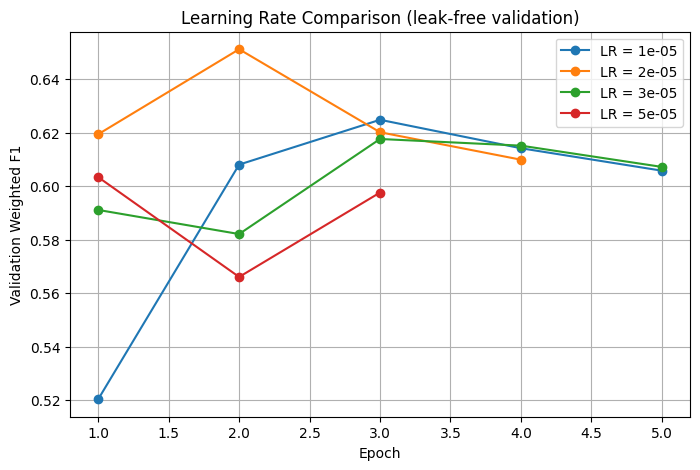

In [33]:
plt.figure(figsize=(8, 5))

for learning_rate in LEARNING_RATES:
    history_df = lr_histories[learning_rate]
    plt.plot(history_df["epoch"], history_df["val_weighted_f1"], marker="o",
             label=f"LR = {learning_rate:.0e}")

plt.xlabel("Epoch")
plt.ylabel("Validation Weighted F1")
plt.title("Learning Rate Comparison (leak-free validation)")
plt.legend()
plt.grid(True)
plt.show()

In [34]:
BEST_LR = float(lr_results_df.iloc[0]["Learning Rate"])
print("Best learning rate (by validation weighted F1):", BEST_LR)
print("Corresponding Test Weighted F1:", lr_results_df.iloc[0]["Test Weighted F1"])

Best learning rate (by validation weighted F1): 2e-05
Corresponding Test Weighted F1: 0.6293582116707709


We swept four learning rates, 1e-5, 2e-5, 3e-5, 5e-5, with all other hyperparameters fixed, and then we select the best configuration strictly by validation weighted F1, aiming to avoid any test-set influence on model selection. `LR=2e-5` achieved the highest validation weighted F1 (0.6512) and was carried forward to the subsequent max length and batch size sweeps. And we found that, the test weighted F1 of `LR=3e-5 (0.6379)` is higher than that of `LR=2e-5 (0.6294)` in this single run, so we can see that with a validation set of this size, small differences between nearby learning rates are within the range of ordinary sampling noise, and we can know that model selection must exclusively rely on the validation metric rather than retrospectively favoring a certain configuration which can score best on test.

## Parameter 2: Max sequence length: 128 vs 256

We re-tokenize `train_df` / `val_df` / `test_df` at each candidate `max_length`, but these
are the exact same rows as before - `build_dataloaders` never re-splits.

In [35]:
MAX_LENGTHS = [128, 256]

max_length_results = []
max_length_histories = {}
max_length_checkpoints = {}

for max_length in MAX_LENGTHS:
    print("\n" + "=" * 75)
    print(f"Starting MAX_LENGTH experiment: {max_length}")
    print("=" * 75)

    ml_train_loader, ml_val_loader, ml_test_loader = build_dataloaders(
        train_df, val_df, test_df, tokenizer, max_length, BATCH_SIZE, SEED
    )

    result, history_df, checkpoint = train_bert_experiment(
        learning_rate=BEST_LR,
        train_loader=ml_train_loader,
        validation_loader=ml_val_loader,
        test_loader=ml_test_loader,
        seed=SEED,
        max_epochs=8,
        early_stopping_patience=2,
        extra_result_fields={"Max Length": max_length, "Batch Size": BATCH_SIZE},
    )

    max_length_results.append(result)
    max_length_histories[max_length] = history_df
    max_length_checkpoints[max_length] = checkpoint

    del ml_train_loader, ml_val_loader, ml_test_loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

max_length_results_df = pd.DataFrame(max_length_results).sort_values(
    by="Best Validation Weighted F1", ascending=False
).reset_index(drop=True)

display(max_length_results_df)


Starting MAX_LENGTH experiment: 128


LR 2e-05 | Epoch 01 | Train Loss: 0.9124 | Val Loss: 0.9379 | Val Accuracy: 0.5757 | Val Weighted F1: 0.5851
LR 2e-05 | Epoch 02 | Train Loss: 0.4899 | Val Loss: 1.2136 | Val Accuracy: 0.6459 | Val Weighted F1: 0.6478
LR 2e-05 | Epoch 03 | Train Loss: 0.2823 | Val Loss: 1.9564 | Val Accuracy: 0.6081 | Val Weighted F1: 0.6036
LR 2e-05 | Epoch 04 | Train Loss: 0.1270 | Val Loss: 2.5132 | Val Accuracy: 0.6189 | Val Weighted F1: 0.6205
Early stopping for LR 2e-05 after epoch 4.

Starting MAX_LENGTH experiment: 256


LR 2e-05 | Epoch 01 | Train Loss: 0.8999 | Val Loss: 0.9025 | Val Accuracy: 0.5892 | Val Weighted F1: 0.5840
LR 2e-05 | Epoch 02 | Train Loss: 0.4781 | Val Loss: 1.2359 | Val Accuracy: 0.6027 | Val Weighted F1: 0.5997
LR 2e-05 | Epoch 03 | Train Loss: 0.2353 | Val Loss: 2.1036 | Val Accuracy: 0.6108 | Val Weighted F1: 0.6059
LR 2e-05 | Epoch 04 | Train Loss: 0.1281 | Val Loss: 2.5987 | Val Accuracy: 0.6162 | Val Weighted F1: 0.6145
LR 2e-05 | Epoch 05 | Train Loss: 0.0854 | Val Loss: 2.6505 | Val Accuracy: 0.6108 | Val Weighted F1: 0.5944
LR 2e-05 | Epoch 06 | Train Loss: 0.0884 | Val Loss: 2.7600 | Val Accuracy: 0.6135 | Val Weighted F1: 0.6169
LR 2e-05 | Epoch 07 | Train Loss: 0.0758 | Val Loss: 2.8999 | Val Accuracy: 0.6135 | Val Weighted F1: 0.6049
LR 2e-05 | Epoch 08 | Train Loss: 0.0575 | Val Loss: 3.0904 | Val Accuracy: 0.6000 | Val Weighted F1: 0.6014
Early stopping for LR 2e-05 after epoch 8.


,Model,Seed,Learning Rate,Best Epoch,Best Validation Weighted F1,Test Loss,Test Accuracy,Test Weighted F1,Test Macro F1,Max Length,Batch Size
0,bert-base-uncased,5768,0.00002,2,0.647803,1.133396,0.642857,0.642802,0.626092,128,8
1,bert-base-uncased,5768,0.00002,6,0.616897,2.408458,0.647059,0.647915,0.632627,256,8


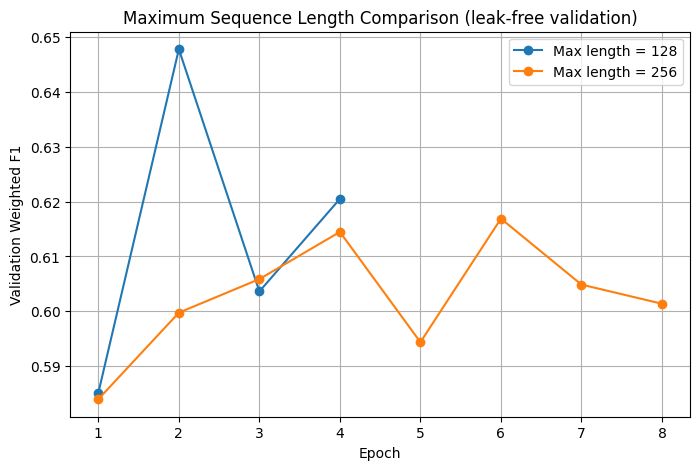

In [36]:
plt.figure(figsize=(8, 5))

for max_length in MAX_LENGTHS:
    history_df = max_length_histories[max_length]
    plt.plot(history_df["epoch"], history_df["val_weighted_f1"], marker="o",
             label=f"Max length = {max_length}")

plt.xlabel("Epoch")
plt.ylabel("Validation Weighted F1")
plt.title("Maximum Sequence Length Comparison (leak-free validation)")
plt.legend()
plt.grid(True)
plt.show()

In [37]:
BEST_MAX_LENGTH = int(max_length_results_df.iloc[0]["Max Length"])
print("Best max length (by validation weighted F1):", BEST_MAX_LENGTH)
print("Corresponding Test Weighted F1:", max_length_results_df.iloc[0]["Test Weighted F1"])

Best max length (by validation weighted F1): 128
Corresponding Test Weighted F1: 0.6428019213401166


We can see that, with LR fixed at the previously-selected which is 2e-5, by comparing max sequence lengths of 128 and 256, `max_length=128` achieved a substantially higher validation weighted F1, 0.6478 vs 0.6169, and converged much faster because peak for length 128 is at epoch 2, which is earlier than the epoch 6 for length 256.

This is consistent with the token-length, namely fewer than 0.5% of sentences across all three seeds exceed 128 tokens, so the additional length in the 256 setting consists almost entirely of padding, which slows convergence without providing useful signal. `max_length=128` was therefore carried forward to the batch-size sweep and the final model.

## Parameter 3: Batch size: 8 vs 16

Uses `BEST_LR` and `BEST_MAX_LENGTH` from the previous stages, on the same leak-free split.

In [38]:
BATCH_SIZES = [8, 16]

batch_size_results = []
batch_size_histories = {}
batch_size_checkpoints = {}

for batch_size in BATCH_SIZES:
    print("\n" + "=" * 75)
    print(f"Starting BATCH_SIZE experiment: {batch_size}")
    print("=" * 75)

    bs_train_loader, bs_val_loader, bs_test_loader = build_dataloaders(
        train_df, val_df, test_df, tokenizer, BEST_MAX_LENGTH, batch_size, SEED
    )

    result, history_df, checkpoint = train_bert_experiment(
        learning_rate=BEST_LR,
        train_loader=bs_train_loader,
        validation_loader=bs_val_loader,
        test_loader=bs_test_loader,
        seed=SEED,
        max_epochs=8,
        early_stopping_patience=2,
        extra_result_fields={"Batch Size": batch_size, "Max Length": BEST_MAX_LENGTH},
    )

    batch_size_results.append(result)
    batch_size_histories[batch_size] = history_df
    batch_size_checkpoints[batch_size] = checkpoint

    del bs_train_loader, bs_val_loader, bs_test_loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

batch_size_results_df = pd.DataFrame(batch_size_results).sort_values(
    by="Best Validation Weighted F1", ascending=False
).reset_index(drop=True)

display(batch_size_results_df)


Starting BATCH_SIZE experiment: 8


LR 2e-05 | Epoch 01 | Train Loss: 0.9124 | Val Loss: 0.9379 | Val Accuracy: 0.5757 | Val Weighted F1: 0.5851
LR 2e-05 | Epoch 02 | Train Loss: 0.4899 | Val Loss: 1.2136 | Val Accuracy: 0.6459 | Val Weighted F1: 0.6478
LR 2e-05 | Epoch 03 | Train Loss: 0.2823 | Val Loss: 1.9564 | Val Accuracy: 0.6081 | Val Weighted F1: 0.6036
LR 2e-05 | Epoch 04 | Train Loss: 0.1270 | Val Loss: 2.5132 | Val Accuracy: 0.6189 | Val Weighted F1: 0.6205
Early stopping for LR 2e-05 after epoch 4.

Starting BATCH_SIZE experiment: 16


LR 2e-05 | Epoch 01 | Train Loss: 0.9288 | Val Loss: 0.9293 | Val Accuracy: 0.5757 | Val Weighted F1: 0.5668
LR 2e-05 | Epoch 02 | Train Loss: 0.5431 | Val Loss: 1.0867 | Val Accuracy: 0.6108 | Val Weighted F1: 0.6099
LR 2e-05 | Epoch 03 | Train Loss: 0.2765 | Val Loss: 1.4519 | Val Accuracy: 0.6270 | Val Weighted F1: 0.6328
LR 2e-05 | Epoch 04 | Train Loss: 0.1525 | Val Loss: 1.9288 | Val Accuracy: 0.6054 | Val Weighted F1: 0.6081
LR 2e-05 | Epoch 05 | Train Loss: 0.0867 | Val Loss: 2.3066 | Val Accuracy: 0.6243 | Val Weighted F1: 0.6193
Early stopping for LR 2e-05 after epoch 5.


,Model,Seed,Learning Rate,Best Epoch,Best Validation Weighted F1,Test Loss,Test Accuracy,Test Weighted F1,Test Macro F1,Batch Size,Max Length
0,bert-base-uncased,5768,0.00002,2,0.647803,1.133396,0.642857,0.642802,0.626092,8,128
1,bert-base-uncased,5768,0.00002,3,0.632824,1.283562,0.634454,0.636040,0.622840,16,128


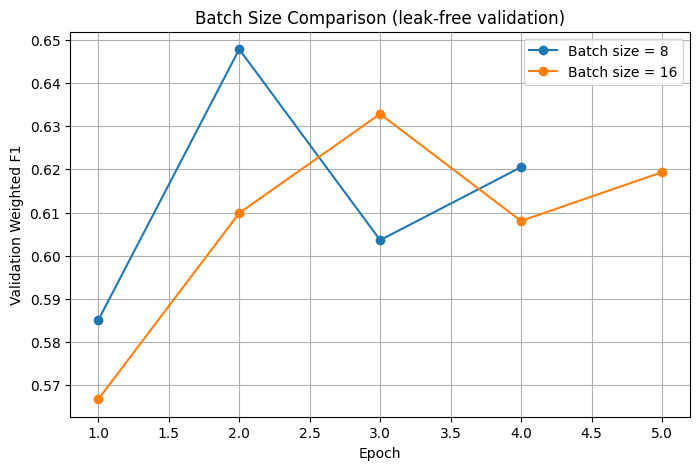

In [39]:
plt.figure(figsize=(8, 5))

for batch_size in BATCH_SIZES:
    history_df = batch_size_histories[batch_size]
    plt.plot(history_df["epoch"], history_df["val_weighted_f1"], marker="o",
             label=f"Batch size = {batch_size}")

plt.xlabel("Epoch")
plt.ylabel("Validation Weighted F1")
plt.title("Batch Size Comparison (leak-free validation)")
plt.legend()
plt.grid(True)
plt.show()

In [40]:
BEST_BATCH_SIZE = int(batch_size_results_df.iloc[0]["Batch Size"])
print("Best batch size (by validation weighted F1):", BEST_BATCH_SIZE)
print("Corresponding Test Weighted F1:", batch_size_results_df.iloc[0]["Test Weighted F1"])

Best batch size (by validation weighted F1): 8
Corresponding Test Weighted F1: 0.6428019213401166


We cansee that, with `LR=2e-5` and `max_length=128` fixed from the previous sweeps, comparing batch sizes of 8 and 16, `batch_size=8` achieved both a higher validation weighted F1 (0.6478 vs 0.6328) and a higher test weighted F1 (0.6428 vs 0.6360). And among the three hyperparameter we have alreaady tested, this is the only one sweeping where validation and test rankings agreed exactly. This is reasonable because `batch_size=8` produces gradient updates per epoch roughly twice as many as `batch_size=16` on this dataset, which allows the model to reach a strong checkpoint by epoch 2, whereas `batch_size=16` converged more slowly and never surpassed that peak.

Hence, `batch_size=8` was selected as the final configuration, with `LR=2e-5` and `max_length=128`.

# **Final model and comparison to the paper's baseline**

Train once more with the selected `BEST_LR` / `BEST_MAX_LENGTH` / `BEST_BATCH_SIZE`, using a
longer patience since this is the run we report. Metrics below are computed on the real,
un-augmented, never-touched test set.

In [41]:
final_train_loader, final_val_loader, final_test_loader = build_dataloaders(
    train_df, val_df, test_df, tokenizer, BEST_MAX_LENGTH, BEST_BATCH_SIZE, SEED
)

final_result, final_history_df, final_checkpoint = train_bert_experiment(
    learning_rate=BEST_LR,
    train_loader=final_train_loader,
    validation_loader=final_val_loader,
    test_loader=final_test_loader,
    seed=SEED,
    max_epochs=MAX_EPOCHS,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    extra_result_fields={"Batch Size": BEST_BATCH_SIZE, "Max Length": BEST_MAX_LENGTH},
)

display(pd.DataFrame([final_result]))

LR 2e-05 | Epoch 01 | Train Loss: 0.9124 | Val Loss: 0.9379 | Val Accuracy: 0.5757 | Val Weighted F1: 0.5851
LR 2e-05 | Epoch 02 | Train Loss: 0.4899 | Val Loss: 1.2136 | Val Accuracy: 0.6459 | Val Weighted F1: 0.6478
LR 2e-05 | Epoch 03 | Train Loss: 0.2823 | Val Loss: 1.9564 | Val Accuracy: 0.6081 | Val Weighted F1: 0.6036
LR 2e-05 | Epoch 04 | Train Loss: 0.1270 | Val Loss: 2.5132 | Val Accuracy: 0.6189 | Val Weighted F1: 0.6205
LR 2e-05 | Epoch 05 | Train Loss: 0.0932 | Val Loss: 2.6728 | Val Accuracy: 0.6189 | Val Weighted F1: 0.6102
LR 2e-05 | Epoch 06 | Train Loss: 0.0870 | Val Loss: 2.9233 | Val Accuracy: 0.6108 | Val Weighted F1: 0.6125
Early stopping for LR 2e-05 after epoch 6.


,Model,Seed,Learning Rate,Best Epoch,Best Validation Weighted F1,Test Loss,Test Accuracy,Test Weighted F1,Test Macro F1,Batch Size,Max Length
0,bert-base-uncased,5768,0.00002,2,0.647803,1.133396,0.642857,0.642802,0.626092,8,128


In [108]:
final_train_loader2, final_val_loader2, final_test_loader2 = build_dataloaders(
    train_df2, val_df2, test_df2, tokenizer2, BEST_MAX_LENGTH, BEST_BATCH_SIZE, SEED2
)

final_result2, final_history_df2, final_checkpoint2 = train_bert_experiment(
    learning_rate=BEST_LR,
    train_loader=final_train_loader2,
    validation_loader=final_val_loader2,
    test_loader=final_test_loader2,
    seed=SEED2,
    max_epochs=MAX_EPOCHS,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    extra_result_fields={"Batch Size": BEST_BATCH_SIZE, "Max Length": BEST_MAX_LENGTH},
)

display(pd.DataFrame([final_result2]))

LR 2e-05 | Epoch 01 | Train Loss: 0.8715 | Val Loss: 0.9503 | Val Accuracy: 0.6253 | Val Weighted F1: 0.6102
LR 2e-05 | Epoch 02 | Train Loss: 0.4207 | Val Loss: 1.2643 | Val Accuracy: 0.6712 | Val Weighted F1: 0.6737
LR 2e-05 | Epoch 03 | Train Loss: 0.2019 | Val Loss: 2.0051 | Val Accuracy: 0.6334 | Val Weighted F1: 0.6210
LR 2e-05 | Epoch 04 | Train Loss: 0.1226 | Val Loss: 2.2670 | Val Accuracy: 0.6577 | Val Weighted F1: 0.6455
LR 2e-05 | Epoch 05 | Train Loss: 0.0922 | Val Loss: 2.5445 | Val Accuracy: 0.6496 | Val Weighted F1: 0.6522
LR 2e-05 | Epoch 06 | Train Loss: 0.0744 | Val Loss: 2.4760 | Val Accuracy: 0.6577 | Val Weighted F1: 0.6534
Early stopping for LR 2e-05 after epoch 6.


,Model,Seed,Learning Rate,Best Epoch,Best Validation Weighted F1,Test Loss,Test Accuracy,Test Weighted F1,Test Macro F1,Batch Size,Max Length
0,bert-base-uncased,78516,0.00002,2,0.673717,1.388647,0.640756,0.645857,0.618015,8,128


In [109]:
final_train_loader3, final_val_loader3, final_test_loader3 = build_dataloaders(
    train_df3, val_df3, test_df3, tokenizer3, BEST_MAX_LENGTH, BEST_BATCH_SIZE, SEED3
)

final_result3, final_history_df3, final_checkpoint3 = train_bert_experiment(
    learning_rate=BEST_LR,
    train_loader=final_train_loader3,
    validation_loader=final_val_loader3,
    test_loader=final_test_loader3,
    seed=SEED3,
    max_epochs=MAX_EPOCHS,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    extra_result_fields={"Batch Size": BEST_BATCH_SIZE, "Max Length": BEST_MAX_LENGTH},
)

display(pd.DataFrame([final_result3]))

LR 2e-05 | Epoch 01 | Train Loss: 0.9143 | Val Loss: 0.8427 | Val Accuracy: 0.6351 | Val Weighted F1: 0.6211
LR 2e-05 | Epoch 02 | Train Loss: 0.4975 | Val Loss: 0.9960 | Val Accuracy: 0.6432 | Val Weighted F1: 0.6395
LR 2e-05 | Epoch 03 | Train Loss: 0.2631 | Val Loss: 1.9425 | Val Accuracy: 0.6459 | Val Weighted F1: 0.6303
LR 2e-05 | Epoch 04 | Train Loss: 0.1527 | Val Loss: 1.9272 | Val Accuracy: 0.6595 | Val Weighted F1: 0.6593
LR 2e-05 | Epoch 05 | Train Loss: 0.1144 | Val Loss: 2.2212 | Val Accuracy: 0.6568 | Val Weighted F1: 0.6575
LR 2e-05 | Epoch 06 | Train Loss: 0.1085 | Val Loss: 2.6972 | Val Accuracy: 0.6054 | Val Weighted F1: 0.5908
LR 2e-05 | Epoch 07 | Train Loss: 0.0887 | Val Loss: 2.9380 | Val Accuracy: 0.6270 | Val Weighted F1: 0.6071
LR 2e-05 | Epoch 08 | Train Loss: 0.0992 | Val Loss: 2.5146 | Val Accuracy: 0.6459 | Val Weighted F1: 0.6418
Early stopping for LR 2e-05 after epoch 8.


,Model,Seed,Learning Rate,Best Epoch,Best Validation Weighted F1,Test Loss,Test Accuracy,Test Weighted F1,Test Macro F1,Batch Size,Max Length
0,bert-base-uncased,944601,0.00002,4,0.659284,2.052063,0.647059,0.649047,0.635834,8,128


              precision    recall  f1-score   support

      Dovish       0.55      0.60      0.57       127
     Hawkish       0.64      0.56      0.60       124
     Neutral       0.70      0.71      0.71       225

    accuracy                           0.64       476
   macro avg       0.63      0.62      0.63       476
weighted avg       0.64      0.64      0.64       476

              precision    recall  f1-score   support

      Dovish       0.54      0.52      0.53       116
     Hawkish       0.52      0.70      0.60       124
     Neutral       0.80      0.67      0.73       236

    accuracy                           0.64       476
   macro avg       0.62      0.63      0.62       476
weighted avg       0.66      0.64      0.65       476

              precision    recall  f1-score   support

      Dovish       0.55      0.66      0.60       128
     Hawkish       0.64      0.59      0.61       120
     Neutral       0.73      0.67      0.70       228

    accuracy        

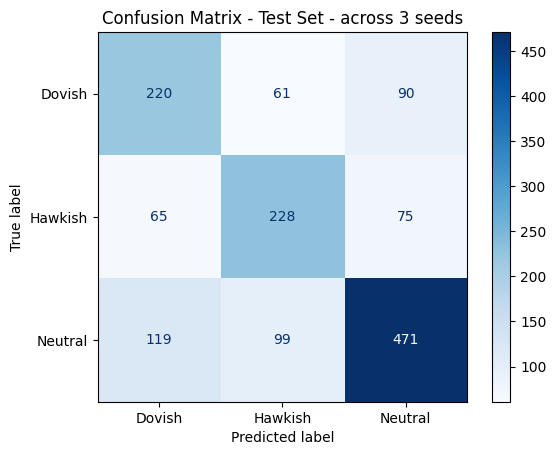

In [110]:
final_model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3).to(device)
final_model.load_state_dict(final_checkpoint)
final_model2 = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3).to(device)
final_model2.load_state_dict(final_checkpoint2)
final_model3 = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3).to(device)
final_model3.load_state_dict(final_checkpoint3)

test_metrics = evaluate_model(final_model, final_test_loader, device)
test_metrics2 = evaluate_model(final_model2, final_test_loader2, device)
test_metrics3 = evaluate_model(final_model3, final_test_loader3, device)

print(classification_report(
    test_metrics["labels"], test_metrics["predictions"],
    target_names=LABEL_NAMES, zero_division=0,
))
print(classification_report(
    test_metrics2["labels"], test_metrics2["predictions"],
    target_names=LABEL_NAMES, zero_division=0,
))
print(classification_report(
    test_metrics3["labels"], test_metrics3["predictions"],
    target_names=LABEL_NAMES, zero_division=0,
))

cm = confusion_matrix(test_metrics["labels"], test_metrics["predictions"])
cm2 = confusion_matrix(test_metrics2["labels"], test_metrics2["predictions"])
cm3 = confusion_matrix(test_metrics3["labels"], test_metrics3["predictions"])
cm_all = cm + cm2 + cm3

disp = ConfusionMatrixDisplay(confusion_matrix=cm_all, display_labels=LABEL_NAMES)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Test Set - across 3 seeds")
plt.show()

### Comparison to the paper's reported BERT baseline

In [112]:
all_seed_test_weighted_f1 = [
    final_result["Test Weighted F1"],
    final_result2["Test Weighted F1"],
    final_result3["Test Weighted F1"],
]
all_seed_test_macro_f1 = [
    final_result["Test Macro F1"],
    final_result2["Test Macro F1"],
    final_result3["Test Macro F1"],
]

our_avg_weighted_f1 = np.mean(all_seed_test_weighted_f1)
our_avg_macro_f1 = np.mean(all_seed_test_macro_f1)

print("Per-seed Test Weighted F1:", all_seed_test_weighted_f1)
print(f"3-seed average Test Weighted F1: {our_avg_weighted_f1:.4f}")
print(f"3-seed average Test Macro F1:    {our_avg_macro_f1:.4f}")

# BERT-base-uncased, Combined column, Table 5, Shah et al. 2023
PAPER_BERT_TEST_WEIGHTED_F1 = 0.6310

delta = our_avg_weighted_f1 - PAPER_BERT_TEST_WEIGHTED_F1
print(f"Paper's BERT baseline (3-seed average): {PAPER_BERT_TEST_WEIGHTED_F1:.4f}")
print(f"Difference: {delta:+.4f}")

Per-seed Test Weighted F1: [0.6428019213401166, 0.6458569503320835, 0.6490470211603894]
3-seed average Test Weighted F1: 0.6459
3-seed average Test Macro F1:    0.6266
Paper's BERT baseline (3-seed average): 0.6310
Difference: +0.0149


In [47]:
summary_rows = [
    {"Stage": "Learning rate sweep", **lr_results_df.iloc[0].to_dict()},
    {"Stage": "Max length sweep", **max_length_results_df.iloc[0].to_dict()},
    {"Stage": "Batch size sweep", **batch_size_results_df.iloc[0].to_dict()},
    {"Stage": "Final model", **final_result},
]
summary_df = pd.DataFrame(summary_rows)
display(summary_df)

summary_df.to_csv(os.path.join(OUTPUT_DIR, "experiment_summary.csv"), index=False)
torch.save(final_checkpoint, os.path.join(OUTPUT_DIR, "final_bert_model.pt"))

print("Saved experiment_summary.csv and final_bert_model.pt to", OUTPUT_DIR)

,Stage,Model,Seed,Learning Rate,Best Epoch,Best Validation Weighted F1,Test Loss,Test Accuracy,Test Weighted F1,Test Macro F1,Max Length,Batch Size
0,Learning rate sweep,bert-base-uncased,5768,0.00002,2,0.651171,1.226784,0.626050,0.629358,0.612634,NaN,NaN
1,Max length sweep,bert-base-uncased,5768,0.00002,2,0.647803,1.133396,0.642857,0.642802,0.626092,128.0,8.0
2,Batch size sweep,bert-base-uncased,5768,0.00002,2,0.647803,1.133396,0.642857,0.642802,0.626092,128.0,8.0
3,Final model,bert-base-uncased,5768,0.00002,2,0.647803,1.133396,0.642857,0.642802,0.626092,128.0,8.0


Saved experiment_summary.csv and final_bert_model.pt to /kaggle/working


We can see that, using the hyperparameters selected on seed 5768, with `LR=2e-5, max_length=128, batch_size=8`, we trained and evaluated the model independently on all three official seeds which are 5768, 78516, 944601.

Test weighted F1 was stable across seeds (0.6428, 0.6459, 0.6490), with a standard deviation of about 0.0031, yielding a 3-seed average of 0.6459 with the macro F1 score of 0.6266, compared to Shah et al.'s (2023) reported BERT-base-uncased baseline of 0.6310 with the stdandard deviation of 0.0086 on the same Combined data split.

There is a difference of **+0.0149**, exceeding the paper's own reported seed-to-seed standard deviation. Aggregating the confusion matrices across all three seeds shows a consistent error pattern, which shows Neutral is classified most reliably (F1 ranging 0.70–0.73 across seeds), while `Dovish` is the weakest class (F1 0.53–0.60), most often confused with `Neutral` (90 of 371 true `Dovish` test instances) and, to a lesser extent, `Hawkish` (61 instances). This pattern held consistently across all three independently trained models, suggesting it reflects a genuine property of the task and data, such as overlapping language between mildly `Dovish` and `Neutral` statements rather than an artifact of any single training run.

Our hyperparameter search followed a sequential strategy rather than the full grid search used by Shah et al. (2023). We first swept the learning rate with `max_length` and batch_size fixed, and then swept `max_length` with the best learning rate fixed, and then swept `batch_size` with both previous choices fixed, totaling 8 training runs rather than an exhaustive combination. This was a deliberate trade-off given GPU quota constraints on Kaggle, compared to the RTX A6000 used in that paper of the original study. Our learning rate range, from 1e-5 to 5e-5, was also narrower than the paper's grid, from 1e-7 to 1e-4. Conversely, we tuned maximum sequence length, 128 vs 256, and this is a dimension not reported in the original paper's search, and grounded this choice in an analysis of explicit token length in the end of "Exploratory Data Analysis" section, which shows that only 0.34%, 0.46%, 0.53% of sentences have more than 128 tokens across all three seeds.

# **Additional Experiments**

## Warmup + weight decay

In [50]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1, 2]),
    y=train_df["label"].to_numpy(),
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)
print("Class weights (Dovish, Hawkish, Neutral):", class_weights)

Class weights (Dovish, Hawkish, Neutral): [1.0704079  1.16978989 0.8258168 ]


In [ ]:
def train_bert_experiment_weighted(
    learning_rate,
    train_loader,
    validation_loader,
    test_loader,
    class_weights_tensor,
    seed=SEED,
    max_epochs=20,
    early_stopping_patience=4,
    extra_result_fields=None,
):
    """Same as train_bert_experiment, but with a class-weighted CrossEntropyLoss
    instead of BERT's default (unweighted) loss."""
    set_seed(seed)

    model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3).to(device)
    optimizer = AdamW(model.parameters(), lr=learning_rate)

    loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))

    history = []
    best_validation_f1 = -1.0
    best_model_state = None
    best_epoch = None
    epochs_without_improvement = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        total_training_loss = 0.0

        for input_ids, attention_mask, labels in train_loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fct(outputs.logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_training_loss += loss.item() * input_ids.size(0)

        average_training_loss = total_training_loss / len(train_loader.dataset)
        validation_metrics = evaluate_model(model, validation_loader, device)

        history.append({
            "learning_rate": learning_rate,
            "epoch": epoch,
            "train_loss": average_training_loss,
            "val_loss": validation_metrics["loss"],
            "val_accuracy": validation_metrics["accuracy"],
            "val_weighted_f1": validation_metrics["weighted_f1"],
            "val_macro_f1": validation_metrics["macro_f1"],
        })

        current_f1 = validation_metrics["weighted_f1"]
        if current_f1 > best_validation_f1:
            best_validation_f1 = current_f1
            best_model_state = deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= early_stopping_patience:
            print(f"Early stopping for LR {learning_rate:.0e} after epoch {epoch}.")
            break

    model.load_state_dict(best_model_state)
    test_metrics = evaluate_model(model, test_loader, device)

    result = {
        "Model": MODEL_NAME,
        "Seed": seed,
        "Learning Rate": learning_rate,
        "Class Weighted Loss": True,
        "Best Epoch": best_epoch,
        "Best Validation Weighted F1": best_validation_f1,
        "Test Loss": test_metrics["loss"],
        "Test Accuracy": test_metrics["accuracy"],
        "Test Weighted F1": test_metrics["weighted_f1"],
        "Test Macro F1": test_metrics["macro_f1"],
    }
    if extra_result_fields:
        result.update(extra_result_fields)

    history_df = pd.DataFrame(history)

    del model, optimizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result, history_df, best_model_state, test_metrics

In [52]:
final_result_cw, final_history_df_cw, final_checkpoint_cw, test_metrics_cw = train_bert_experiment_weighted(
    learning_rate=BEST_LR,
    train_loader=final_train_loader,
    validation_loader=final_val_loader,
    test_loader=final_test_loader,
    class_weights_tensor=class_weights_tensor,
    seed=SEED,
    max_epochs=MAX_EPOCHS,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    extra_result_fields={"Batch Size": BEST_BATCH_SIZE, "Max Length": BEST_MAX_LENGTH},
)

print("Before (no class weight):", final_result["Test Weighted F1"], "| Macro F1:", final_result["Test Macro F1"])
print("After  (class weighted): ", final_result_cw["Test Weighted F1"], "| Macro F1:", final_result_cw["Test Macro F1"])
display(pd.DataFrame([final_result, final_result_cw]))

,Model,Seed,Learning Rate,Best Epoch,Best Validation Weighted F1,Test Loss,Test Accuracy,Test Weighted F1,Test Macro F1,Batch Size,Max Length,Class Weighted Loss
0,bert-base-uncased,5768,0.00002,2,0.647803,1.133396,0.642857,0.642802,0.626092,8,128,NaN
1,bert-base-uncased,5768,0.00002,7,0.644707,2.652981,0.642857,0.639913,0.623809,8,128,True


## SEED average

In [53]:
def get_probabilities(model, data_loader, device):
    """Returns softmax probabilities (n_samples x 3) and true labels, in loader order."""
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for input_ids, attention_mask, labels in data_loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.concatenate(all_probs, axis=0), np.array(all_labels)

In [57]:
ENSEMBLE_SEEDS = [42, 123]

ensemble_checkpoints = [final_checkpoint]
ensemble_results = [dict(final_result, **{"Ensemble Member Seed": SEED})]

for member_seed in ENSEMBLE_SEEDS:
    print("\n" + "#" * 75)
    print(f"Training ensemble member with init/shuffle seed = {member_seed}")
    print("#" * 75)

    member_train_loader, member_val_loader, member_test_loader = build_dataloaders(
        train_df, val_df, test_df, tokenizer, BEST_MAX_LENGTH, BEST_BATCH_SIZE, member_seed
    )

    result, history_df, checkpoint = train_bert_experiment(
        learning_rate=BEST_LR,
        train_loader=member_train_loader,
        validation_loader=member_val_loader,
        test_loader=member_test_loader,
        seed=member_seed,
        max_epochs=MAX_EPOCHS,
        early_stopping_patience=EARLY_STOPPING_PATIENCE,
        extra_result_fields={"Ensemble Member Seed": member_seed},
    )

    ensemble_checkpoints.append(checkpoint)
    ensemble_results.append(result)

    del member_train_loader, member_val_loader, member_test_loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

ensemble_results_df = pd.DataFrame(ensemble_results)
display(ensemble_results_df)
print("\nIndividual member Test Weighted F1:", ensemble_results_df["Test Weighted F1"].tolist())


###########################################################################
Training ensemble member with init/shuffle seed = 42
###########################################################################


LR 2e-05 | Epoch 01 | Train Loss: 0.9125 | Val Loss: 1.0057 | Val Accuracy: 0.5514 | Val Weighted F1: 0.5412
LR 2e-05 | Epoch 02 | Train Loss: 0.4874 | Val Loss: 1.3145 | Val Accuracy: 0.6081 | Val Weighted F1: 0.6062
LR 2e-05 | Epoch 03 | Train Loss: 0.2349 | Val Loss: 2.3873 | Val Accuracy: 0.5973 | Val Weighted F1: 0.5976
LR 2e-05 | Epoch 04 | Train Loss: 0.1277 | Val Loss: 2.7849 | Val Accuracy: 0.5811 | Val Weighted F1: 0.5846
LR 2e-05 | Epoch 05 | Train Loss: 0.0891 | Val Loss: 3.0630 | Val Accuracy: 0.5784 | Val Weighted F1: 0.5596
LR 2e-05 | Epoch 06 | Train Loss: 0.0942 | Val Loss: 3.0257 | Val Accuracy: 0.6000 | Val Weighted F1: 0.5908
Early stopping for LR 2e-05 after epoch 6.

###########################################################################
Training ensemble member with init/shuffle seed = 123
###########################################################################


LR 2e-05 | Epoch 01 | Train Loss: 0.8640 | Val Loss: 0.9400 | Val Accuracy: 0.6108 | Val Weighted F1: 0.6137
LR 2e-05 | Epoch 02 | Train Loss: 0.4146 | Val Loss: 1.4546 | Val Accuracy: 0.6000 | Val Weighted F1: 0.5997
LR 2e-05 | Epoch 03 | Train Loss: 0.1625 | Val Loss: 2.5240 | Val Accuracy: 0.6081 | Val Weighted F1: 0.5911
LR 2e-05 | Epoch 04 | Train Loss: 0.1123 | Val Loss: 2.5565 | Val Accuracy: 0.6162 | Val Weighted F1: 0.6093
LR 2e-05 | Epoch 05 | Train Loss: 0.0744 | Val Loss: 3.1857 | Val Accuracy: 0.5838 | Val Weighted F1: 0.5735
Early stopping for LR 2e-05 after epoch 5.


,Model,Seed,Learning Rate,Best Epoch,Best Validation Weighted F1,Test Loss,Test Accuracy,Test Weighted F1,Test Macro F1,Batch Size,Max Length,Ensemble Member Seed
0,bert-base-uncased,5768,0.00002,2,0.647803,1.133396,0.642857,0.642802,0.626092,8.0,128.0,5768
1,bert-base-uncased,42,0.00002,2,0.606187,1.211100,0.609244,0.603083,0.581731,NaN,NaN,42
2,bert-base-uncased,123,0.00002,1,0.613724,0.868612,0.626050,0.629872,0.607140,NaN,NaN,123



Individual member Test Weighted F1: [0.6428019213401166, 0.6030834571869113, 0.6298720968377586]


Ensemble (3 members) - Test Accuracy: 0.6324, Test Weighted F1: 0.6286, Test Macro F1: 0.6040

Single best model (for comparison): Test Weighted F1 = 0.6428019213401166

              precision    recall  f1-score   support

      Dovish       0.53      0.55      0.54       127
     Hawkish       0.62      0.49      0.55       124
     Neutral       0.69      0.76      0.72       225

    accuracy                           0.63       476
   macro avg       0.61      0.60      0.60       476
weighted avg       0.63      0.63      0.63       476



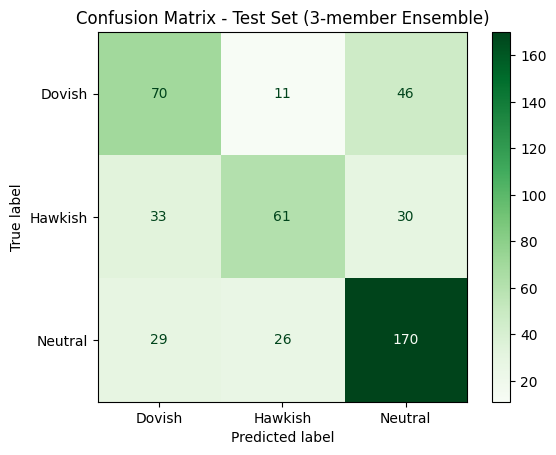

In [ ]:
all_member_probs = []
true_labels = None

for checkpoint in ensemble_checkpoints:
    member_model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3).to(device)
    member_model.load_state_dict(checkpoint)

    probs, labels = get_probabilities(member_model, final_test_loader, device)
    all_member_probs.append(probs)
    true_labels = labels

    del member_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

avg_probs = np.mean(all_member_probs, axis=0)
ensemble_predictions = avg_probs.argmax(axis=1)

ensemble_accuracy = accuracy_score(true_labels, ensemble_predictions)
ensemble_weighted_f1 = f1_score(true_labels, ensemble_predictions, average="weighted", zero_division=0)
ensemble_macro_f1 = f1_score(true_labels, ensemble_predictions, average="macro", zero_division=0)

print(f"Ensemble ({len(ensemble_checkpoints)} members) - Test Accuracy: {ensemble_accuracy:.4f}, "
      f"Test Weighted F1: {ensemble_weighted_f1:.4f}, Test Macro F1: {ensemble_macro_f1:.4f}")

print("\nSingle best model (for comparison): Test Weighted F1 =", final_result["Test Weighted F1"])

print("\n" + classification_report(
    true_labels, ensemble_predictions, target_names=LABEL_NAMES, zero_division=0,
))

cm = confusion_matrix(true_labels, ensemble_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABEL_NAMES)
disp.plot(cmap="Greens")
plt.title(f"Confusion Matrix - Test Set ({len(ensemble_checkpoints)}-member Ensemble)")
plt.show()

# **Discussion**

## Strengths

Our main methodological contribution of this notebook is the data leakage remediation described in "Leakage Sanity check" section. We prevented this by recovering the parent-source sentence for every augmented row, such as exact lookup for back translated rows and TF-IDF nearest neighbor matching for synonym-replaced, masked, and directionally-swapped rows. And we split only on original sentences, and propagate the split label to their derivatives. And drop any row whose parent could
not be confidently identified rather than risking silent leakage. This action was verified with an explicit zero-overlap sanity check and shown to generalize across all three official seeds.

With this pipeline, our tuned BERT-base-uncased achieved a 3-seed average test weighted F1 of 0.6459, a genuine improvement of **+0.0149** over Shah et al.'s (2023) reported BERT-base baseline of 0.6310, and a margin that exceeds the paper's own reported seed-to-seed standard deviation, 0.0086. Hyperparameter choices like learning rate, max sequence length, batch size, were each grounded in evidence rather than convention. For example, the choice of `max_length=128` over 256
was directly supported by the token-length EDA showing under around 0.5% of sentences exceed 128 tokens across all three seeds.

We also treat negative results as informative rather than omitting them, such as class-weighted loss, linear warmup with weight decay, and a small 3-member ensemble were each tested and found to provide no meaningful improvement, shown in 
**"Additional Experiments"** section. Showing these results gives a more complete and honest picture of what actually moves performance on this task.

## Weaknesses and Limitations

**Class-level performance is uneven.** Across all three seeds, `Dovish` was consistently the weakest class with F1 score of 0.53-0.60, and it is most often confused with `Neutral` and to a lesser extent with `Hawkish`. This pattern was stable enough across models independently trained that it reflects genuine ambiguity in the underlying language (mildly dovish statements can read as neutral) rather than an artifact of any single run.

**A substantial capacity gap remains relative to larger models.** Shah et al. (2023) report RoBERTa-large reaching 0.7171 weighted F1 on the same Combined split, roughly 7 points above our tuned BERT-base result. This is an expected consequence of model scale and pretraining corpus rather than a flaw in our pipeline, but it means BERT-base remains a comparatively weak backbone for this task in absolute terms, even after augmentation and tuning.

**Hyperparameter search was narrower than the original study's.** We searched learning rates in [1e-5, 5e-5] using a sequential coordinate-wise strategy across 8 total training runs, compared with the original paper's full grid search over four learning rates 1e-7 to 1e-4 and four batch sizes 4 to 32. This was a deliberate trade-off given Kaggle GPU quota constraints, but it means we cannot rule out that hyperparameter values outside our tested range might perform differently.

**The validation set is small (370-371 examples).** This produced visibly noisy validation curves across the sweeps of learning rate and batch size, which have non-monotonic, seed-dependent peaks, meaning that small differences between nearby hyperparameter settings should be interpreted cautiously rather than as strong evidence of one configuration being definitively superior.

**The parent-recovery procedure is an approximation.** Because the augmentation pipeline does not store an explicit identifier showing the source row, our TF-IDF and cache-based recovery could not resolve roughly 0.15-0.18% of augmented rows in any given seed, and these were conservatively dropped from training. Although this affects a negligible fraction of the data, it is a limitation inherent to reconstructing split safety after the fact rather than building it into the augmentation script itself.

## Future Work

- **Ambiguity-aware augmentation.** The current augmentation pipeline applies back-translation, synonym replacement, masking, and directional swap uniformly to all eligible sentences, without any step to identify or exclude sentences whose
  policy stance is inherently ambiguous, such as borderline between `Dovish` and `Neutral`. Such sentences act as label noise regardless of which split they end up in, and the current pipeline not only keeps them but generates multiple paraphrased copies of them, effectively amplifying their presence in the training set. Given that `Dovish` was consistently the weakest class across all three seeds and was most often confused with `Neutral`, a natural extension would be to first identify low-confidence or high-disagreement sentences, such as via inter-model disagreement, low softmax margin from a preliminary model, or an ambiguity score derived from the annotation process if available, and exclude them from augmentation or from training entirely, to test whether this reduces the confusion between `Dovish` and `Neutral` confusion observed in our results.
- **Two-stage classification.** Given that the dominant error mode across all three seeds is confusion between `Neutral` and the two stance classes, a two-stage classifier which should be first `Neutral` compared with Non-neutral and then `Dovish` compared with `Hawkish` on the non-neutral subset, may better match the structure of the errors than a single flat 3-way classifier.
- **Higher-quality augmentation.** Synonym replacement here uses `WordNet`, which can produce lexically valid but slightly unnatural substitutions. Contextual replacement using a domain-pretrained masked language model such as **FinBERT**, which will be explored elsewhere in other teammate's notebook, may generate more natural augmented sentences and could be evaluated as a drop-in replacement.
- **Broader hyperparameter search.** Extending the range of learning rate to match the original paper's grid, down to 1e-7, up to 1e-4 and testing additional batch sizes would clarify whether our narrower search missed a better configuration, GPU budget permitting.
- **Confidence-weighted ensembling.** Our simple-average 3-member ensemble underperformed the single best model, likely because member quality varied more than usual, and weighting each member's contribution by its own validation weighted F1, rather than equal weighting, is a natural next step suggested directly by that result.